In [2]:
import os
import re
import openpyxl
import xlsxwriter
import csv
import pandas as pd
from datetime import datetime
import pandas as pd
import matplotlib.patches as patches
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample
from scipy.stats import pearsonr
import pickle
import seaborn as sns
import matplotlib as mpl
from typing import List, Dict, Optional
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Define helper functions

In [3]:
def save_dataframe_to_files(df, pathname, filename):
    """
    Save a pandas DataFrame to both CSV and Excel formats in the specified location.
    Creates directories if they don't exist.
    """
    # Ensure the filename doesn't include extensions
    base_name = os.path.splitext(filename)[0]
    
    # Create directory if it doesn't exist
    os.makedirs(pathname, exist_ok=True)
    
    # Create full paths
    csv_path = os.path.join(pathname, f"{base_name}.csv")
    excel_path = os.path.join(pathname, f"{base_name}.xlsx")
    
    try:
        # Save files
        df.to_csv(csv_path, index=False)
        df.to_excel(excel_path, index=False, engine='openpyxl')
        
        print(f"Files saved successfully:\n- {csv_path}\n- {excel_path}")
    except Exception as e:
        print(f"Error saving files: {str(e)}")

In [4]:
def get_bootstrap_ci(bootstrap_distribution, confidence_level=0.95):
    alpha = 1 - confidence_level
    lower = np.percentile(bootstrap_distribution, (alpha / 2) * 100).round(3)
    upper = np.percentile(bootstrap_distribution, (1 - alpha / 2) * 100).round(3)
    mean = np.mean(bootstrap_distribution).round(3)
    median = np.median(bootstrap_distribution).round(3)
    std = np.std(bootstrap_distribution).round(3)
    
    return {
        'Mean': mean,
        'Median': median,
        'Std': std,
        'CI_lower': lower,
        'CI_upper': upper
    }

In [5]:
def compute_and_save_bootstrap_results_1level(
    metrics: List[str],
    modality_name: str,
    base_path: str,
    output_path: str,
    ci_level: float = 0.95,
    column_order: Optional[List[str]] = None,
    print_summary: bool = True
) -> pd.DataFrame:
    
    # Default column order
    if column_order is None:
        column_order = ['Modality', 'Metric', 'Mean', 'Median', 'Std', 'CI_lower', 'CI_upper']
    
    ci_results = []
    
    for metric in metrics:
        # Load bootstrap results
        try:
            file_path = os.path.join(base_path, f"{modality_name}_{metric}_bootstrapped_renamed.csv")
            df = pd.read_csv(file_path)
            
            # Clean columns
            df = df.drop(
                columns=df.columns[df.columns.str.contains('^Unnamed|^index$', case=False)], 
                errors='ignore'
            )
            
        except FileNotFoundError:
            print(f"Warning: File not found for {modality_name}_{metric}")
            continue
        
        # Process each modality column
        for modality in df.columns:
            if df[modality].isna().all():
                print(f"Skipping empty modality: {modality}")
                continue
                
            values = df[modality].values
            lower, upper = get_bootstrap_ci(values, ci_level)
            
            ci_results.append({
                'Modality': modality,
                'Metric': metric.upper(),
                'Mean': np.mean(values).round(3),
                'Median': np.median(values).round(3),
                'Std': np.std(values).round(3),
                'CI_lower': lower,
                'CI_upper': upper
            })
    
    # Create and format DataFrame
    ci_df = pd.DataFrame(ci_results)
    
    # Ensure all expected columns exist
    missing_cols = [col for col in column_order if col not in ci_df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected columns: {missing_cols}")
    
    ci_df = ci_df[column_order]
    
    # Save results
    output_filename = f'bootstrap_{modality_name}_pls_CI'
    save_dataframe_to_files(ci_df, output_path, output_filename)
    
    # Print results
    if print_summary:
        print_results(ci_df, output_path)
    
    return ci_df


def print_results(ci_df: pd.DataFrame, output_path: str) -> None:
    """Print formatted results summary."""
    print("=== Confidence Intervals ===")
    print(ci_df)
    print(f"\nResults saved to: {output_path}")
    
    for modality, group in ci_df.groupby('Modality'):
        print(f"\n=== {modality} ===")
        for metric, metric_group in group.groupby('Metric'):
            row = metric_group.iloc[0]
            print(f"{row['Metric']}:")
            print(f"  Mean ± SD: {row['Mean']} ± {row['Std']}")
            print(f"  Median: {row['Median']}")
            print(f"  95% CI: [{row['CI_lower']}, {row['CI_upper']}]")

In [6]:
def compute_and_save_bootstrap_results_2level(
    bootstrap_dists: dict,
    output_path: str,
    modality_name: str = None,
    algorithms: list = ['SVR', 'eNet', 'RF', 'XGB']
) -> pd.DataFrame:

    # Initialize results storage
    ci_results = {
        'Modality': [],
        'Algorithm': [],
        'Metric': [],
        'Mean': [],
        'Median': [],
        'Std': [],
        'CI_lower': [],
        'CI_upper': []
    }

    for algorithm in algorithms:
        print(f"\n=== {algorithm} ===")
        
        for metric, dist in bootstrap_dists.items():
            try:
                alg_data = dist[algorithm]
                
                # Calculate statistics
                mean_val = np.mean(alg_data).round(3)
                median_val = np.median(alg_data).round(3)
                std_val = np.std(alg_data).round(3)
                lower, upper = get_bootstrap_ci(alg_data)
                
                # Store results (including modality if provided)
                if modality_name:
                    ci_results['Modality'].append(modality_name)
                ci_results['Algorithm'].append(algorithm)
                ci_results['Metric'].append(metric)
                ci_results['Mean'].append(mean_val)
                ci_results['Median'].append(median_val)
                ci_results['Std'].append(std_val)
                ci_results['CI_lower'].append(lower)
                ci_results['CI_upper'].append(upper)
                
                print(f"{metric}:")
                print(f"  Mean ± SD: {mean_val} ± {std_val}")
                print(f"  Median: {median_val}")
                print(f"  95% CI: [{lower}, {upper}]")
                
            except KeyError:
                print(f"Warning: {algorithm} not found in {metric} data")
                continue

    # Convert to DataFrame
    try:
        # Define expected columns (including Modality if needed)
        expected_columns = (['Modality'] if modality_name else []) + [
            'Algorithm', 'Metric', 'Mean', 'Median', 'Std', 'CI_lower', 'CI_upper'
        ]
        
        ci_df = pd.DataFrame(ci_results)
        
        # Verify columns
        missing_cols = [col for col in expected_columns if col not in ci_df.columns]
        if missing_cols:
            raise ValueError(f"Missing columns: {missing_cols}")
            
        ci_df = ci_df[expected_columns]
        
        # Create filename with modality if provided
        timestamp = datetime.now().strftime("%Y%m%d_%H%M")
        base_filename = f"bootstrap_{modality_name}_CI" if modality_name else f"bootstrap_CI"
        
        save_dataframe_to_files(ci_df, output_path, base_filename)
        
        print("\n=== Final Results ===")
        print(ci_df)
        print(f"\nResults saved to: {output_path}")
        
        return ci_df
        
    except Exception as e:
        print(f"Error processing results: {str(e)}")
        return None

In [7]:
def print_results(ci_df, output_path):
    print("=== Confidence Intervals ===")
    print(ci_df)
    print(f"\nResults saved to: {output_path}")
    for modality, group in ci_df.groupby('Modality'):
        print(f"\n=== {modality} ===")
        for metric, metric_group in group.groupby('Metric'):
            row = metric_group.iloc[0]
            print(f"{row['Metric']}:")
            print(f"  Mean ± SD: {row['Mean']} ± {row['Std']}")
            print(f"  Median: {row['Median']}")
            print(f"  95% CI: [{row['CI_lower']}, {row['CI_upper']}]")

In [8]:
# Define brain and body modalities
###############################################################
modalities_brain_body_behav = [
'activity_touchscreen',
'accelerometry',
'activity_MET',
'activity_byrecall_i3',
'sleep_ac',
'localenv',
'diet',
'electronic_device_use',
'alcohol',
'sun_i0',
'sexual_factors',
'smoking',
#######################
'immune',
'renalhepatic',
'metabolic',
'cardiopulmonary',
'musculoskeletal',
'bone_densitometry',
'pwa',
'heart_mri',
'carotid_ultrasound',
'arterial_stiffness',
'ecg_rest',
'body_composition_by_impedance',
'body_composition_dxa',
'bone_dxa',
'kidneys_mri',
'liver_mri',
'abdominal_composition_mri_18_vars', #17 vars
'abdominal_organ_composition_mri_13_vars', #12 vars
'hearing',
#######################
'struct_fast',
'struct_sub_first',
'struct_fs_aseg_mean_intensity',
'struct_fs_aseg_volume',
'struct_ba_exvivo_area', 
'struct_ba_exvivo_mean_thickness',
'struct_ba_exvivo_volume',
'struct_a2009s_area',
'struct_a2009s_mean_thickness',
'struct_a2009s_volume',
'struct_dkt_area',
'struct_dkt_mean_thickness',
'struct_dkt_volume',
'struct_desikan_gw',
'struct_desikan_pial',
'struct_desikan_white_area',
'struct_desikan_white_mean_thickness',
'struct_desikan_white_volume',
'struct_subsegmentation',
'add_t1',
'add_t2',

"dwi_FA_tbss", "dwi_FA_prob",
"dwi_MD_tbss", "dwi_MD_prob",
"dwi_L1_tbss", "dwi_L1_prob",
"dwi_L2_tbss", "dwi_L2_prob",
"dwi_L3_tbss", "dwi_L3_prob",
"dwi_MO_tbss", "dwi_MO_prob",
"dwi_OD_tbss", "dwi_OD_prob",
"dwi_ICVF_tbss", "dwi_ICVF_prob",
"dwi_ISOVF_tbss", "dwi_ISOVF_prob",

'aparc_Tian_S1_FA_i2',
'aparc_Tian_S1_Length_i2',
'aparc_Tian_S1_SIFT2_FBC_i2',
'aparc_Tian_S1_Streamline_Count_i2',

'aparc_a2009s_Tian_S1_FA_i2',
'aparc_a2009s_Tian_S1_Length_i2',
'aparc_a2009s_Tian_S1_SIFT2_FBC_i2',
'aparc_a2009s_Tian_S1_Streamline_Count_i2',

'Glasser_Tian_S1_FA_i2',
'Glasser_Tian_S1_Length_i2',
'Glasser_Tian_S1_SIFT2_FBC_i2',
'Glasser_Tian_S1_Streamline_Count_i2',

'Glasser_Tian_S4_FA_i2',
'Glasser_Tian_S4_Length_i2',
'Glasser_Tian_S4_SIFT2_FBC_i2',
'Glasser_Tian_S4_Streamline_Count_i2',

'Schaefer7n200p_Tian_S1_FA_i2',
'Schaefer7n200p_Tian_S1_Length_i2',
'Schaefer7n200p_Tian_S1_SIFT2_FBC_i2',
'Schaefer7n200p_Tian_S1_Streamline_Count_i2',

'Schaefer7n1000p_Tian_S4_FA_i2',
'Schaefer7n1000p_Tian_S4_Length_i2',
'Schaefer7n1000p_Tian_S4_SIFT2_FBC_i2',
'Schaefer7n1000p_Tian_S4_Streamline_Count_i2',

"amplitudes_21",
"full_correlation_21",
"partial_correlation_21",
"amplitudes_55",
"full_correlation_55",
"partial_correlation_55",
'full_correlation_aparc_a2009s_Tian_S1',
'full_correlation_aparc_Tian_S1',
'full_correlation_Glasser_Tian_S1',
'full_correlation_Glasser_Tian_S4',
'full_correlation_Schaefer7n200p_Tian_S1',
'full_correlation_Schaefer7n500p_Tian_S4',
'partial_correlation_aparc_a2009s_Tian_S1',
'partial_correlation_aparc_Tian_S1',
'partial_correlation_Glasser_Tian_S1',
'partial_correlation_Glasser_Tian_S4',
'partial_correlation_Schaefer7n200p_Tian_S1',
'partial_correlation_Schaefer7n500p_Tian_S4'
]

modalities_brain = [
'struct_fast',
'struct_sub_first',
'struct_fs_aseg_mean_intensity',
'struct_fs_aseg_volume',
'struct_ba_exvivo_area', 
'struct_ba_exvivo_mean_thickness',
'struct_ba_exvivo_volume',
'struct_a2009s_area',
'struct_a2009s_mean_thickness',
'struct_a2009s_volume',
'struct_dkt_area',
'struct_dkt_mean_thickness',
'struct_dkt_volume',
'struct_desikan_gw',
'struct_desikan_pial',
'struct_desikan_white_area',
'struct_desikan_white_mean_thickness',
'struct_desikan_white_volume',
'struct_subsegmentation',
'add_t1',
'add_t2',

"dwi_FA_tbss", "dwi_FA_prob",
"dwi_MD_tbss", "dwi_MD_prob",
"dwi_L1_tbss", "dwi_L1_prob",
"dwi_L2_tbss", "dwi_L2_prob",
"dwi_L3_tbss", "dwi_L3_prob",
"dwi_MO_tbss", "dwi_MO_prob",
"dwi_OD_tbss", "dwi_OD_prob",
"dwi_ICVF_tbss", "dwi_ICVF_prob",
"dwi_ISOVF_tbss", "dwi_ISOVF_prob",

'aparc_Tian_S1_FA_i2',
'aparc_Tian_S1_Length_i2',
'aparc_Tian_S1_SIFT2_FBC_i2',
'aparc_Tian_S1_Streamline_Count_i2',

'aparc_a2009s_Tian_S1_FA_i2',
'aparc_a2009s_Tian_S1_Length_i2',
'aparc_a2009s_Tian_S1_SIFT2_FBC_i2',
'aparc_a2009s_Tian_S1_Streamline_Count_i2',

'Glasser_Tian_S1_FA_i2',
'Glasser_Tian_S1_Length_i2',
'Glasser_Tian_S1_SIFT2_FBC_i2',
'Glasser_Tian_S1_Streamline_Count_i2',

'Glasser_Tian_S4_FA_i2',
'Glasser_Tian_S4_Length_i2',
'Glasser_Tian_S4_SIFT2_FBC_i2',
'Glasser_Tian_S4_Streamline_Count_i2',

'Schaefer7n200p_Tian_S1_FA_i2',
'Schaefer7n200p_Tian_S1_Length_i2',
'Schaefer7n200p_Tian_S1_SIFT2_FBC_i2',
'Schaefer7n200p_Tian_S1_Streamline_Count_i2',

'Schaefer7n1000p_Tian_S4_FA_i2',
'Schaefer7n1000p_Tian_S4_Length_i2',
'Schaefer7n1000p_Tian_S4_SIFT2_FBC_i2',
'Schaefer7n1000p_Tian_S4_Streamline_Count_i2',

"amplitudes_21",
"full_correlation_21",
"partial_correlation_21",
"amplitudes_55",
"full_correlation_55",
"partial_correlation_55",
'full_correlation_aparc_a2009s_Tian_S1',
'full_correlation_aparc_Tian_S1',
'full_correlation_Glasser_Tian_S1',
'full_correlation_Glasser_Tian_S4',
'full_correlation_Schaefer7n200p_Tian_S1',
'full_correlation_Schaefer7n500p_Tian_S4',
'partial_correlation_aparc_a2009s_Tian_S1',
'partial_correlation_aparc_Tian_S1',
'partial_correlation_Glasser_Tian_S1',
'partial_correlation_Glasser_Tian_S4',
'partial_correlation_Schaefer7n200p_Tian_S1',
'partial_correlation_Schaefer7n500p_Tian_S4'
]
modalities_body = [
'immune',
'renalhepatic',
'metabolic',
'cardiopulmonary',
'musculoskeletal',
'bone_densitometry',
'pwa',
'heart_mri',
'carotid_ultrasound',
'arterial_stiffness',
'ecg_rest',
'body_composition_by_impedance',
'body_composition_dxa',
'bone_dxa',
'kidneys_mri',
'liver_mri',
'abdominal_composition_mri_18_vars', #17 vars
'abdominal_organ_composition_mri_13_vars', #12 vars
'hearing'
]

modalities_behav = [
'activity_touchscreen',
'accelerometry',
'activity_MET',
'activity_byrecall_i3',
'sleep_ac',
'localenv',
'diet',
'electronic_device_use',
'alcohol',
'sun_i0',
'sexual_factors',
'smoking'
]

In [9]:
# Define modality map to rename modalities
modality_map = {
'hearing': 'Hearing',
'immune': 'Immune',
'renalhepatic': 'Renal & Hepatic',
'metabolic': 'Metabolic',
'cardiopulmonary': 'Cardiopulmonary',
'musculoskeletal': 'Musculoskeletal',
'bone_densitometry': 'Bone densitometry (of heel)',
'pwa': 'Pulse Wave Analysis',
'heart_mri': 'Heart MRI',
'carotid_ultrasound': 'Carotid Ultrasound',
'arterial_stiffness': 'Arterial Stiffness',
'ecg_rest': 'ECG at Rest',
'body_composition_by_impedance': 'Body Composition by Impedance',
'body_composition_dxa': 'Body composition by DXA',
'bone_dxa': 'Bone size, mineral and density by DXA',
'kidneys_mri': 'Kidney MRI',
'liver_mri': 'Liver MRI',
'abdominal_composition_mri_18_vars': 'Abdominal Composition by MRI',
'abdominal_organ_composition_mri_13_vars': 'Abdominal Organ Composition by MRI',
'struct_fast' : 'Regional grey matter volumes (FSL FAST)',
'struct_sub_first': 'Subcortical volumes (FSL FIRST)',

'struct_fs_aseg_mean_intensity' : 'ASEG Mean Intensity',
'struct_fs_aseg_volume' : 'ASEG Volume',


'struct_ba_exvivo_area' : 'BA ex-vivo Area',
'struct_ba_exvivo_mean_thickness' : 'BA ex-vivo Mean Thickness',
'struct_ba_exvivo_volume' : 'BA ex-vivo Volume',

'struct_a2009s_area' : 'a2009s Area',
'struct_a2009s_mean_thickness' : 'a2009s Mean Thickness',
'struct_a2009s_volume' : 'a2009s Volume',


'struct_dkt_area' : 'Desikan-Killiany-Tourville Area',
'struct_dkt_mean_thickness' : 'Desikan-Killiany-Tourville Mean Thickness',
'struct_dkt_volume' : 'Desikan-Killiany-Tourville Volume',


'struct_desikan_gw' : 'Desikan Grey\White Matter Contrast',
'struct_desikan_pial' : 'Desikan Pial',

'struct_desikan_white_area' : 'Desikan White Matter Area',
'struct_desikan_white_mean_thickness' : 'Desikan White Matter Mean Thickness',
'struct_desikan_white_volume' : 'Desikan White Matter Volume',
"struct_subsegmentation":'Subcortical Volumetric Subsegmentation',

'add_t1' : 'Whole-brain T1w',
'add_t2' : 'Whole-brain T2w',
"dwi_FA_tbss": "FA TBSS",
"dwi_FA_prob": "FA Prob.",
"dwi_MD_tbss": "MD TBSS",
"dwi_MD_prob": "MD Prob.",
"dwi_L1_tbss": "L1 TBSS",
"dwi_L1_prob": "L1 Prob.",
"dwi_L2_tbss": "L2 TBSS",
"dwi_L2_prob": "L2 Prob.",
"dwi_L3_tbss": "L3 TBSS",
"dwi_L3_prob": "L3 Prob.",
"dwi_MO_tbss": "MO TBSS",
"dwi_MO_prob": "MO Prob.",
"dwi_OD_tbss": "OD TBSS",
"dwi_OD_prob": "OD Prob.",
"dwi_ICVF_tbss": "ICVF TBSS",
"dwi_ICVF_prob": "ICVF Prob.",
"dwi_ISOVF_tbss": "ISOVF TBSS",
"dwi_ISOVF_prob": "ISOVF Prob.",
"amplitudes_21": " 21 IC amplitudes",
"amplitudes_55": "55 IC amplitudes",
"full_correlation_21": "21 IC Full corr.",
"full_correlation_55": "55 IC Full corr.",
"partial_correlation_21": " 21 IC Partial Corr.",
"partial_correlation_55": " 55 IC Partial Corr.",
# aparc Tian S1 (I)
'aparc_Tian_S1_FA_i2': 'aparc-I FA',
'aparc_Tian_S1_Length_i2': 'aparc-I Length',
'aparc_Tian_S1_SIFT2_FBC_i2': 'aparc-I SIFT2 FBC',
'aparc_Tian_S1_Streamline_Count_i2': 'aparc-I Streamline Count',

# aparc a2009s Tian S1 (I)
'aparc_a2009s_Tian_S1_FA_i2': 'aparc.a2009s-I FA',
'aparc_a2009s_Tian_S1_Length_i2': 'aparc.a2009s-I Length',
'aparc_a2009s_Tian_S1_SIFT2_FBC_i2': 'aparc.a2009s-I SIFT2 FBC',
'aparc_a2009s_Tian_S1_Streamline_Count_i2': 'aparc.a2009s-I Streamline Count',

# Glasser Tian S1 (I)
'Glasser_Tian_S1_FA_i2': 'Glasser-I FA',
'Glasser_Tian_S1_Length_i2': 'Glasser-I Length',
'Glasser_Tian_S1_SIFT2_FBC_i2': 'Glasser-I SIFT2 FBC',
'Glasser_Tian_S1_Streamline_Count_i2': 'Glasser-I Streamline Count',

# Glasser Tian S4 (IV)
'Glasser_Tian_S4_FA_i2': 'Glasser-IV FA',
'Glasser_Tian_S4_Length_i2': 'Glasser-IV Length',
'Glasser_Tian_S4_SIFT2_FBC_i2': 'Glasser-IV SIFT2 FBC',
'Glasser_Tian_S4_Streamline_Count_i2': 'Glasser-IV Streamline Count',

# Schaefer7n1000p Tian S4 (IV) (in reality: Schaefer7n200p Tian S1)
'Schaefer7n1000p_Tian_S4_FA_i2': 'Schaefer7n200p-I FA', #'Schaefer7n1000p-IV FA',
'Schaefer7n1000p_Tian_S4_Length_i2': 'Schaefer7n200p-I Length',#'Schaefer7n1000p-IV Length',
'Schaefer7n1000p_Tian_S4_SIFT2_FBC_i2': 'Schaefer7n200p-I SIFT2 FBC',#'Schaefer7n1000p-IV SIFT2 FBC',
'Schaefer7n1000p_Tian_S4_Streamline_Count_i2': 'Schaefer7n200p-I Streamline Count', #'Schaefer7n1000p-IV Streamline Count'

# Schaefer7n200p Tian S4 (IV) (in reality: Schaefer7n500p Tian S4)
'Schaefer7n200p_Tian_S1_FA_i2': 'Schaefer7n500p-IV FA',
'Schaefer7n200p_Tian_S1_Length_i2': 'Schaefer7n500p-IV Length',
'Schaefer7n200p_Tian_S1_SIFT2_FBC_i2': 'Schaefer7n500p-IV SIFT2 FBC',
'Schaefer7n200p_Tian_S1_Streamline_Count_i2': 'Schaefer7n500p-IV Streamline Count',

# Schaefer7n500p Tian S4 (IV) (in reality: Schaefer7n1000p Tian S4)
'Schaefer7n500p_Tian_S4_FA_i2': 'Schaefer7n1000p-IV FA',
'Schaefer7n500p_Tian_S4_Length_i2': 'Schaefer7n1000p-IV Length',
'Schaefer7n500p_Tian_S4_SIFT2_FBC_i2': 'Schaefer7n1000p-IV SIFT2 FBC',
'Schaefer7n500p_Tian_S4_Streamline_Count_i2': 'Schaefer7n1000p-IV Streamline Count',

# Resting state 
'full_correlation_aparc_a2009s_Tian_S1' : 'aparc.a2009s-I Full Corr.',
'full_correlation_aparc_Tian_S1': 'aparc-I Full Corr.',
'full_correlation_Glasser_Tian_S1': 'Glasser-I Full Corr.',
'full_correlation_Glasser_Tian_S4': 'Glasser-IV Full Corr.',
'full_correlation_Schaefer7n200p_Tian_S1': 'Schaefer7n200p-I Full Corr.',
'full_correlation_Schaefer7n500p_Tian_S4': 'Schaefer7n500p-IV Full Corr.',
'partial_correlation_aparc_a2009s_Tian_S1': 'aparc.a2009s-I Partial Corr.',
'partial_correlation_aparc_Tian_S1': 'aparc-I Partial Corr.',
'partial_correlation_Glasser_Tian_S1': 'Glasser-I Partial Corr.',
'partial_correlation_Glasser_Tian_S4': 'Glasser-IV Partial Corr.',
'partial_correlation_Schaefer7n200p_Tian_S1': 'Schaefer7n200p-I Partial Corr.',
'partial_correlation_Schaefer7n500p_Tian_S4': 'Schaefer7n500p-IV Partial Corr.',


'activity_touchscreen' :'Activity: Daily behaviour',
'accelerometry':'Activity: Accelerometry',
'activity_MET':'Activity: MET',
'activity_byrecall_i3':'Activity: Online (by recall)',
'sleep_ac':'Sleep',
'localenv':'Local environment',
'diet':'Diet',
'electronic_device_use':'Electronic device use',
'alcohol':'Alcohol',
'sun_i0':'Sun exposure',
'sexual_factors':'Sexual Factors',
'smoking':'Smoking',

'lifestyle-envir': 'Lifestyle & Environment',

'allmri': '3 Brain MRI Modalities Stacked',
'dwi': 'Brain dwMRI Stacked',
'smri': 'Brain sMRI Stacked',
'rs': 'Brain rsMRI Stacked',
'body': 'Body Physiology Stacked',
'lifestyle-envir': 'Lifestyle & Environment',
'brain-plus-body': '3 Brain MRI Modalities & Body Stacked',
'brain-body': 'Brain & Body Stacked',
'body-only': 'Body Physiology Stacked',
'all': 'Behaviour, body, and brain stacked'
}

In [ ]:
# Configurations
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Configuration
folds = range(0, 5)
base_path = '/UK_BB/brainbody'
fig_path = '/UK_BB/brainbody/figures'

# Define paths with proper formatting
paths = {
        'behav': {
            'train': os.path.join(base_path, 'lifestyle-envir-body', 'folds', 'fold_{}', 'g_pred', '{}_g_pred_XGB_train_with_id_fold_{}.csv'),
            'test': os.path.join(base_path, 'lifestyle-envir-body', 'folds', 'fold_{}', 'g_pred', '{}_g_pred_XGB_test_with_id_fold_{}.csv')
        },
        'body': {
            'train': os.path.join(base_path, 'lifestyle-envir-body', 'folds', 'fold_{}', 'g_pred', '{}_g_pred_XGB_train_with_id_fold_{}.csv'),
            'test': os.path.join(base_path, 'lifestyle-envir-body', 'folds', 'fold_{}', 'g_pred', '{}_g_pred_XGB_test_with_id_fold_{}.csv')
        },
            'brain': {
            'train': os.path.join(base_path, 'brain', 'folds', 'fold_{}', 'g_pred', '{}_g_pred_XGB_train_with_id_fold_{}.csv'),
            'test': os.path.join(base_path, 'brain', 'folds', 'fold_{}', 'g_pred', '{}_g_pred_XGB_test_with_id_fold_{}.csv')
        },
        'g_observed': {
            'train': os.path.join(base_path, 'cognition', 'folds', 'fold_{}', 'g', 'g_train_with_id_{}.csv'),
            'test': os.path.join(base_path, 'cognition', 'folds', 'fold_{}', 'g', 'g_test_with_id_{}.csv')
        }
    }

# First-level

## Behavioural

In [ ]:
# Combine data across 5 folds
bootstrapping_path = '/UK_BB/brainbody/bootstrap/behav'
os.makedirs(bootstrapping_path, exist_ok=True)
for modality in modalities_behav:
    pred_list = []

    for fold in folds:
        pred_path = paths['behav']['test'].format(fold, modality, fold)
        obs_path = paths['g_observed']['test'].format(fold, fold)

        df_pred = pd.read_csv(pred_path)
        df_obs = pd.read_csv(obs_path).rename(columns={'g': 'g_obs_test'})

        # Merge on ID (assuming 'eid' exists in both)
        df = pd.merge(df_obs, df_pred, on='eid', how='inner')
        pred_list.append(df)

    combined = pd.concat(pred_list, ignore_index=True)

    # Save combined file
    out_file = os.path.join(bootstrapping_path, f'{modality}_folds_combined_test.csv')
    combined.to_csv(out_file, index=False)
    print(f"Saved combined file for {modality}: {combined.shape}")

In [ ]:
# Bootstrap behaviour
boot = 5000
metrics = ['R2', 'r', 'MSE', 'MAE']
bootstrapping_path = '/UK_BB/brainbody/bootstrap/behav'
# Create a single results directory
results_dir = os.path.join(bootstrapping_path, 'results')
os.makedirs(results_dir, exist_ok=True)

# Process each modality
for modality in modalities_behav:
    print(f"\nProcessing {modality}...")
    
    # Load the combined test data for this modality
    input_path = os.path.join(bootstrapping_path, f'{modality}_folds_combined_test.csv')
    df = pd.read_csv(input_path)
    
    # Initialize results storage
    bootstrap_results = {metric: [] for metric in metrics}
    
    # Run bootstrap
    for i in tqdm(range(boot), desc=f"Bootstrapping {modality}"):
        df_sample = df.sample(len(df), replace=True) 
        
        # Calculate metrics with error handling
        try:
            corr, _ = pearsonr(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            r2 = r2_score(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            mse = mean_squared_error(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            mae = mean_absolute_error(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
                    
            bootstrap_results['r'].append(corr)
            bootstrap_results['R2'].append(r2)
            bootstrap_results['MSE'].append(mse)
            bootstrap_results['MAE'].append(mae)
        except Exception as e:
            print(f"Error in bootstrap iteration {i}: {str(e)}")
            continue
    
    # Convert results to a DataFrame
    results_df = pd.DataFrame({
        f"{modality}_r": bootstrap_results['r'],
        f"{modality}_R2": bootstrap_results['R2'],
        f"{modality}_MSE": bootstrap_results['MSE'],
        f"{modality}_MAE": bootstrap_results['MAE']
    })
    
    # Save bootstrap results to the common results folder
    results_df.to_csv(os.path.join(results_dir, f'{modality}_bootstrapped.csv'), index=False)
    print(f"Bootstrap results for {modality} saved to {results_dir}")

# Compute and save combined CI results
all_ci_results = []

for modality in modalities_behav:
    # Load the bootstrap results
    bootstrap_file = os.path.join(results_dir, f'{modality}_bootstrapped.csv')
    if not os.path.exists(bootstrap_file):
        print(f"Warning: Bootstrap file not found for {modality}")
        continue
        
    df = pd.read_csv(bootstrap_file)
    
    # Process each metric
    for metric in metrics:
        col_name = f"{modality}_{'r' if metric == 'r' else metric}"
        
        if col_name not in df.columns:
            print(f"Warning: Column {col_name} not found in bootstrap results for {modality}")
            continue
            
        values = df[col_name].dropna().values  # Remove any NA values
        
        if len(values) == 0:
            print(f"Warning: No valid values for {modality} {metric}")
            continue
            
        ci_stats = get_bootstrap_ci(values)
        
        all_ci_results.append({
            'Modality': modality,
            'Metric': metric,
            'Mean': ci_stats['Mean'],
            'Median': ci_stats['Median'],
            'Std': ci_stats['Std'],
            'CI_lower': ci_stats['CI_lower'],
            'CI_upper': ci_stats['CI_upper']
        })

# Create and save final CI results
if all_ci_results:
    ci_df = pd.DataFrame(all_ci_results)
    
    # Reorder columns
    column_order = ['Modality', 'Metric', 'Mean', 'Median', 'Std', 'CI_lower', 'CI_upper']
    ci_df = ci_df[column_order]
    
    # Save in both CSV and Excel formats
    save_dataframe_to_files(ci_df, results_dir, 'combined_bootstrap_CI_results')
    
    # Print summary
    print("\n=== Final Bootstrap Confidence Intervals ===")
    print_results(ci_df, results_dir)
else:
    print("Warning: No valid bootstrap results were generated")

In [ ]:
# Rename modalities and sort by Pearson r
results_path = os.path.join(base_path, 'bootstrap', 'behav', 'results', 'combined_bootstrap_CI_results.xlsx')
ci_df = pd.read_excel(results_path)
ci_df['Modality'] = ci_df['Modality'].replace(modality_map)

# Extract r values for sorting
r_values = ci_df[ci_df['Metric'] == 'r'].set_index('Modality')['Mean']

# Create a custom sorter
modality_order = r_values.sort_values(ascending=False).index.tolist()

# Convert Modality to categorical with the custom order
ci_df['Modality'] = pd.Categorical(ci_df['Modality'], 
                                 categories=modality_order,
                                 ordered=True)

# Define metric order within each modality
metric_order = ['r', 'R2', 'MSE', 'MAE']
ci_df['Metric'] = pd.Categorical(ci_df['Metric'], 
                               categories=metric_order,
                               ordered=True)

# Sort first by Modality, then by Metric
ci_df = ci_df.sort_values(['Modality', 'Metric'])
ci_df = ci_df.reset_index(drop=True)
save_dataframe_to_files(ci_df, os.path.join(base_path, 'bootstrap', 'behav', 'results'), 'combined_bootstrap_CI_results_sorted')
print("Successfully sorted with metrics grouped by modality!")

## Body

In [ ]:
# Combine data across 5 folds
bootstrapping_path = '/UK_BB/brainbody/bootstrap/body'
os.makedirs(bootstrapping_path, exist_ok=True)
for modality in modalities_body:
    pred_list = []
    for fold in folds:
        pred_path = paths['body']['test'].format(fold, modality, fold)
        obs_path = paths['g_observed']['test'].format(fold, fold)

        df_pred = pd.read_csv(pred_path)
        df_obs = pd.read_csv(obs_path).rename(columns={'g': 'g_obs_test'})

        # Merge on ID (assuming 'eid' exists in both)
        df = pd.merge(df_obs, df_pred, on='eid', how='inner')
        pred_list.append(df)

    combined = pd.concat(pred_list, ignore_index=True)

    # Save combined file
    out_file = os.path.join(bootstrapping_path, f'{modality}_folds_combined_test.csv')
    combined.to_csv(out_file, index=False)
    print(f"Saved combined file for {modality}: {combined.shape}")

In [ ]:
# Bootstrap body
boot = 5000
metrics = ['R2', 'r', 'MSE', 'MAE']
bootstrapping_path = '/UK_BB/brainbody/bootstrap/body'
# Create a single results directory
results_dir = os.path.join(bootstrapping_path, 'results')
os.makedirs(results_dir, exist_ok=True)

# Process each modality
for modality in modalities_body:
    print(f"\nProcessing {modality}...")
    
    # Load the combined test data for this modality
    input_path = os.path.join(bootstrapping_path, f'{modality}_folds_combined_test.csv')
    df = pd.read_csv(input_path)
    
    # Initialize results storage
    bootstrap_results = {metric: [] for metric in metrics}
    
    # Run bootstrap
    for i in tqdm(range(boot), desc=f"Bootstrapping {modality}"):
        df_sample = df.sample(len(df), replace=True) 
        
        # Calculate metrics with error handling
        try:
            corr, _ = pearsonr(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            r2 = r2_score(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            mse = mean_squared_error(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            mae = mean_absolute_error(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
                    
            bootstrap_results['r'].append(corr)
            bootstrap_results['R2'].append(r2)
            bootstrap_results['MSE'].append(mse)
            bootstrap_results['MAE'].append(mae)
        except Exception as e:
            print(f"Error in bootstrap iteration {i}: {str(e)}")
            continue
    
    # Convert results to a DataFrame
    results_df = pd.DataFrame({
        f"{modality}_r": bootstrap_results['r'],
        f"{modality}_R2": bootstrap_results['R2'],
        f"{modality}_MSE": bootstrap_results['MSE'],
        f"{modality}_MAE": bootstrap_results['MAE']
    })
    
    # Save bootstrap results to the common results folder
    results_df.to_csv(os.path.join(results_dir, f'{modality}_bootstrapped.csv'), index=False)
    print(f"Bootstrap results for {modality} saved to {results_dir}")

# Compute and save combined CI results
all_ci_results = []

for modality in modalities_body:
    # Load the bootstrap results
    bootstrap_file = os.path.join(results_dir, f'{modality}_bootstrapped.csv')
    if not os.path.exists(bootstrap_file):
        print(f"Warning: Bootstrap file not found for {modality}")
        continue
        
    df = pd.read_csv(bootstrap_file)
    
    # Process each metric
    for metric in metrics:
        col_name = f"{modality}_{'r' if metric == 'r' else metric}"
        
        if col_name not in df.columns:
            print(f"Warning: Column {col_name} not found in bootstrap results for {modality}")
            continue
            
        values = df[col_name].dropna().values  # Remove any NA values
        
        if len(values) == 0:
            print(f"Warning: No valid values for {modality} {metric}")
            continue
            
        ci_stats = get_bootstrap_ci(values)
        
        all_ci_results.append({
            'Modality': modality,
            'Metric': metric,
            'Mean': ci_stats['Mean'],
            'Median': ci_stats['Median'],
            'Std': ci_stats['Std'],
            'CI_lower': ci_stats['CI_lower'],
            'CI_upper': ci_stats['CI_upper']
        })

# Create and save final CI results
if all_ci_results:
    ci_df = pd.DataFrame(all_ci_results)
    
    # Reorder columns
    column_order = ['Modality', 'Metric', 'Mean', 'Median', 'Std', 'CI_lower', 'CI_upper']
    ci_df = ci_df[column_order]
    
    # Save in both CSV and Excel formats
    save_dataframe_to_files(ci_df, results_dir, 'combined_bootstrap_CI_results')
    
    # Print summary
    print("\n=== Final Bootstrap Confidence Intervals ===")
    print_results(ci_df, results_dir)
else:
    print("Warning: No valid bootstrap results were generated")

In [ ]:
# Rename modalities and sort by Pearson r
results_path = os.path.join(base_path, 'bootstrap', 'body', 'results', 'combined_bootstrap_CI_results.xlsx')
ci_df = pd.read_excel(results_path)
ci_df['Modality'] = ci_df['Modality'].replace(modality_map)

# Extract r values for sorting
r_values = ci_df[ci_df['Metric'] == 'r'].set_index('Modality')['Mean']

# Create a custom sorter
modality_order = r_values.sort_values(ascending=False).index.tolist()

# Convert Modality to categorical with the custom order
ci_df['Modality'] = pd.Categorical(ci_df['Modality'], 
                                 categories=modality_order,
                                 ordered=True)

# Define metric order within each modality
metric_order = ['r', 'R2', 'MSE', 'MAE']
ci_df['Metric'] = pd.Categorical(ci_df['Metric'], 
                               categories=metric_order,
                               ordered=True)

# Sort first by Modality, then by Metric
ci_df = ci_df.sort_values(['Modality', 'Metric'])
ci_df = ci_df.reset_index(drop=True)
save_dataframe_to_files(ci_df, os.path.join(base_path, 'bootstrap', 'body', 'results'), 'combined_bootstrap_CI_results_sorted')
print("Successfully sorted with metrics grouped by modality!")

## Brain

In [ ]:
# Combine data across 5 folds
bootstrapping_path = '/UK_BB/brainbody/bootstrap/brain'
for modality in modalities_brain:
    pred_list = []

    for fold in folds:
        pred_path = paths['brain']['test'].format(fold, modality, fold)
        obs_path = paths['g_observed']['test'].format(fold, fold)

        df_pred = pd.read_csv(pred_path)
        df_obs = pd.read_csv(obs_path).rename(columns={'g': 'g_obs_test'})

        # Merge on ID (assuming 'eid' exists in both)
        df = pd.merge(df_obs, df_pred, on='eid', how='inner')
        pred_list.append(df)

    combined = pd.concat(pred_list, ignore_index=True)

    # Save combined file
    out_file = os.path.join(bootstrapping_path, f'{modality}_folds_combined_test.csv')
    combined.to_csv(out_file, index=False)
    print(f"Saved combined file for {modality}: {combined.shape}")

In [ ]:
# Bootstrap brain
boot = 5000
metrics = ['R2', 'r', 'MSE', 'MAE']

bootstrapping_path = '/UK_BB/brainbody/bootstrap/brain'
os.makedirs(bootstrapping_path, exist_ok=True)

# Create a single results directory
results_dir = os.path.join(bootstrapping_path, 'results')
os.makedirs(results_dir, exist_ok=True)

# Process each modality
for modality in modalities_brain:
    print(f"\nProcessing {modality}...")
    
    # Load the combined test data for this modality
    input_path = os.path.join(bootstrapping_path, f'{modality}_folds_combined_test.csv')
    df = pd.read_csv(input_path)
    
    # Initialize results storage
    bootstrap_results = {metric: [] for metric in metrics}
    
    # Run bootstrap
    for i in tqdm(range(boot), desc=f"Bootstrapping {modality}"):
        df_sample = df.sample(len(df), replace=True) 
        
        # Calculate metrics with error handling
        try:
            corr, _ = pearsonr(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            r2 = r2_score(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            mse = mean_squared_error(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
            mae = mean_absolute_error(df_sample['g_obs_test'], df_sample[f'g_pred_test_{modality}'])
                    
            bootstrap_results['r'].append(corr)
            bootstrap_results['R2'].append(r2)
            bootstrap_results['MSE'].append(mse)
            bootstrap_results['MAE'].append(mae)
        except Exception as e:
            print(f"Error in bootstrap iteration {i}: {str(e)}")
            continue
    
    # Convert results to a DataFrame
    results_df = pd.DataFrame({
        f"{modality}_r": bootstrap_results['r'],
        f"{modality}_R2": bootstrap_results['R2'],
        f"{modality}_MSE": bootstrap_results['MSE'],
        f"{modality}_MAE": bootstrap_results['MAE']
    })
    
    # Save bootstrap results to the common results folder
    results_df.to_csv(os.path.join(results_dir, f'{modality}_bootstrapped.csv'), index=False)
    print(f"Bootstrap results for {modality} saved to {results_dir}")

# Compute and save combined CI results
all_ci_results = []

for modality in modalities_brain:
    # Load the bootstrap results
    bootstrap_file = os.path.join(results_dir, f'{modality}_bootstrapped.csv')
    if not os.path.exists(bootstrap_file):
        print(f"Warning: Bootstrap file not found for {modality}")
        continue
        
    df = pd.read_csv(bootstrap_file)
    
    # Process each metric
    for metric in metrics:
        col_name = f"{modality}_{'r' if metric == 'r' else metric}"
        
        if col_name not in df.columns:
            print(f"Warning: Column {col_name} not found in bootstrap results for {modality}")
            continue
            
        values = df[col_name].dropna().values
        
        if len(values) == 0:
            print(f"Warning: No valid values for {modality} {metric}")
            continue
            
        ci_stats = get_bootstrap_ci(values)
        
        all_ci_results.append({
            'Modality': modality,
            'Metric': metric,
            'Mean': ci_stats['Mean'],
            'Median': ci_stats['Median'],
            'Std': ci_stats['Std'],
            'CI_lower': ci_stats['CI_lower'],
            'CI_upper': ci_stats['CI_upper']
        })

# Create and save final CI results
if all_ci_results:
    ci_df = pd.DataFrame(all_ci_results)
    
    # Reorder columns
    column_order = ['Modality', 'Metric', 'Mean', 'Median', 'Std', 'CI_lower', 'CI_upper']
    ci_df = ci_df[column_order]
    
    # Save in both CSV and Excel formats
    save_dataframe_to_files(ci_df, results_dir, 'combined_bootstrap_CI_results')
    
    # Print summary
    print("\n=== Final Bootstrap Confidence Intervals ===")
    print_results(ci_df, results_dir)
else:
    print("Warning: No valid bootstrap results were generated")

In [ ]:
# Rename modalities and sort by Pearson r
results_path = os.path.join(base_path, 'bootstrap', 'brain', 'results', 'combined_bootstrap_CI_results.xlsx')
ci_df = pd.read_excel(results_path)
ci_df['Modality'] = ci_df['Modality'].replace(modality_map)

# Extract r values for sorting
r_values = ci_df[ci_df['Metric'] == 'r'].set_index('Modality')['Mean']

# Create a custom sorter
modality_order = r_values.sort_values(ascending=False).index.tolist()

# Convert Modality to categorical with the custom order
ci_df['Modality'] = pd.Categorical(ci_df['Modality'], 
                                 categories=modality_order,
                                 ordered=True)

# Define metric order within each modality
metric_order = ['r', 'R2', 'MSE', 'MAE']
ci_df['Metric'] = pd.Categorical(ci_df['Metric'], 
                               categories=metric_order,
                               ordered=True)

# Sort first by Modality, then by Metric
ci_df = ci_df.sort_values(['Modality', 'Metric'])
ci_df = ci_df.reset_index(drop=True)
save_dataframe_to_files(ci_df, os.path.join(base_path, 'bootstrap', 'brain', 'results'), 'combined_bootstrap_CI_results_sorted')
print("Successfully sorted with metrics grouped by modality!")

# Stacked models

In [ ]:
# Combine data across 5 folds: Configuration
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Configuration
folds = range(5)
base_path = '/UK_BB/brainbody'
bootstrapping_path = '/UK_BB/brainbody/bootstrap/stack/behav/scaled'
os.makedirs(bootstrapping_path, exist_ok=True)

# Define path templates with correct structure
stacking_paths = {
    'body': {
        'submodalities': ['body'],
        'pred_pattern': os.path.join(base_path, 'stacking', 'body', 'folds', 'fold_{fold}', 'g_pred', '{submod}_target_pred_2nd_level_0_outer_test_fold_{fold}.csv'),
    },
    'behav': {
        'submodalities': ['lifestyle-envir'],
        'pred_pattern': os.path.join(base_path, 'stacking', 'lifestyle-envir', 'folds', 'fold_{fold}', 'g_pred', '{submod}_target_pred_2nd_level_0_outer_test_fold_{fold}.csv'),
    },
    'brain': {
        'submodalities': ['allmri', 'dwi', 'rs', 'smri'],
        'pred_pattern': os.path.join(base_path, 'stacking', 'brain', '{submod}', 'folds', 'fold_{fold}', 'g_pred', '{submod}_target_pred_2nd_level_rf_test_fold_{fold}.csv')
    },
    'brain-body': {
        'submodalities': ['brain-body'],
        'pred_pattern': os.path.join(base_path, 'stacking', 'brain-body', 'folds', 'fold_{fold}', 'g_pred', '{submod}_target_pred_2nd_level_0_outer_test_fold_{fold}.csv')
    },
        'all': {
        'submodalities': ['all'],
        'pred_pattern': os.path.join(base_path, 'stacking', 'all', 'folds', 'fold_{fold}', 'g_pred', '{submod}_target_pred_2nd_level_rf_outer_test_fold_{fold}.csv')
    },
    'g_observed': {
        'test': os.path.join(base_path, 'cognition', 'folds', 'fold_{fold}', 'g', 'g_test_with_id_{fold}.csv')
    }
}

In [ ]:
# Define a function to combine data across folds with inverse scaling
def combine_folds(modality_type):
    for submod in stacking_paths[modality_type]['submodalities']:
        combined_df = pd.DataFrame()
        
        for fold in folds:
            # 1. Load prediction data
            pred_path = stacking_paths[modality_type]['pred_pattern'].format(
                fold=fold,
                submod=submod
            )
            # 2. Load observed data
            obs_path = stacking_paths['g_observed']['test'].format(fold=fold)
            
            try:
                df_pred = pd.read_csv(pred_path)
                df_obs = pd.read_csv(obs_path).rename(columns={'g': 'g_obs_test'})
                
                # 3. Load the target scaler for this specific fold and modality
                # Build the path to the scaler
                if modality_type == 'brain':
                    # Path for brain submodalities: base_path\stacking', 'brain\{submod}\folds\fold_{fold}\suppl\
                    scaler_path = os.path.join(
                        base_path, 'stacking', 'brain', submod, 
                        'folds', f'fold_{fold}', 'suppl', 
                        f'{submod}_scaler_target_fold_{fold}.pkl'
                    )
                elif modality_type == 'body':
                    # Path for body: base_path\stacking', 'body\folds\fold_{fold}\suppl\
                    scaler_path = os.path.join(
                        base_path, 'stacking', 'body', 
                        'folds', f'fold_{fold}', 'suppl', 
                        f'body_scaler_target_fold_{fold}.pkl'
                    )

                elif modality_type == 'behav':
                    # Path for body: base_path\stacking', 'lifestyle-envir\folds\fold_{fold}\suppl\
                    scaler_path = os.path.join(
                        base_path, 'stacking', 'lifestyle-envir', 
                        'folds', f'fold_{fold}', 'suppl', 
                        f'lifestyle-envir_scaler_target_fold_{fold}.pkl'
                    )
                elif modality_type == 'all':
                    # Path for body: base_path\stacking', 'all\folds\fold_{fold}\suppl\
                    scaler_path = os.path.join(
                        base_path, 'stacking', 'all', 
                        'folds', f'fold_{fold}', 'suppl', 
                        f'all_scaler_target_fold_{fold}.pkl'
                    )
                elif modality_type == 'brain-body':
                    # Path for brain-body: base_path\stacking', 'brain-body\folds\fold_{fold}\suppl\
                    scaler_path = os.path.join(
                        base_path, 'stacking', 'brain-body', 
                        'folds', f'fold_{fold}', 'suppl', 
                        f'brain-body_scaler_target_fold_{fold}.pkl'
                    )
                
                # Load the scaler
                with open(scaler_path, 'rb') as f:
                    target_scaler = pickle.load(f)
                
                # 4. Inverse transform the predictions to get them back to original scale
                # Find the prediction column (e.g., 'g_pred_stack_test', 'g_pred_test_{submod}', etc.)
                pred_col = [col for col in df_pred.columns if 'pred' in col.lower() and 'g' in col.lower()][0]
                
                # Reshape, inverse transform, and assign back to DataFrame
                predictions_scaled = df_pred[pred_col].values.reshape(-1, 1)
                predictions_original_scale = target_scaler.inverse_transform(predictions_scaled)
                df_pred[pred_col] = predictions_original_scale
                
                # 5. Merge on eid
                df_merged = pd.merge(df_obs, df_pred, on='eid', how='inner')
                
                # 6. Add a column to remember which fold this data came from
                df_merged['fold'] = fold
                
                combined_df = pd.concat([combined_df, df_merged], ignore_index=True)
                
            except FileNotFoundError as e:
                print(f"Scaler or data file not found for {submod} fold {fold}: {str(e)}")
                continue
            except Exception as e:
                print(f"Error processing {submod} fold {fold}: {str(e)}")
                continue
        
        # Save combined file
        output_file = os.path.join(bootstrapping_path, f'{submod}_folds_combined_test.csv')
        combined_df.to_csv(output_file, index=False)
        print(f"Saved combined {submod} data: {combined_df.shape}")
        print(f"Sample predictions: {combined_df[pred_col].head()}")
        print(f"Sample observations: {combined_df['g_obs_test'].head()}")

Here we use the target scaler to inverse‑transform predictions because the model outputs values in the scaled target space (since the target and features were scaled before performing stacking). Therefore,  the target scaler defines the mapping back to the original g‑factor units.

In [ ]:
# Process each modality
print("Combining behavioural modalities...")
combine_folds('behav')

print("Combining body modalities...")
combine_folds('body')

print("\nCombining brain modalities...")
combine_folds('brain')

print("\nCombining brain-body modalities...")
combine_folds('brain-body')

print("\nCombining all modalities...")
combine_folds('all')

print("\nAll data combined and saved to:", bootstrapping_path)

In [ ]:
# Bootstrap
boot = 5000
metrics = ['R2', 'r', 'MSE', 'MAE']
bootstrapping_path = '/UK_BB/brainbody/bootstrap/stack/behav/scaled'

# Create results directory
results_dir = os.path.join(bootstrapping_path, 'results')
os.makedirs(results_dir, exist_ok=True)

# Define all modalities to process
all_modalities = (
    stacking_paths['behav']['submodalities'] + 
    stacking_paths['body']['submodalities'] + 
    stacking_paths['brain']['submodalities'] + 
    stacking_paths['brain-body']['submodalities'] +
    stacking_paths['all']['submodalities']
)

# Process each modality
for modality in all_modalities:
    print(f"\nProcessing {modality}...")
    
    # Load the combined test data
    input_path = os.path.join(bootstrapping_path, f'{modality}_folds_combined_test.csv')
    df = pd.read_csv(input_path)
    
    # Initialize results storage
    bootstrap_results = {metric: [] for metric in metrics}
    
    # Run bootstrap
    for i in tqdm(range(boot), desc=f"Bootstrapping {modality}"):
        df_sample = df.sample(len(df), replace=True) 
        
        # Calculate metrics with error handling
        try:
            # For stacked predictions, the column name is just 'g_pred' (not 'g_pred_test_{modality}')
            pred_col = 'g_pred_stack_test' if 'g_pred_stack_test' in df_sample.columns else f'g_pred_test_{modality}'
            
            corr, _ = pearsonr(df_sample['g_obs_test'], df_sample[pred_col])
            r2 = r2_score(df_sample['g_obs_test'], df_sample[pred_col])
            mse = mean_squared_error(df_sample['g_obs_test'], df_sample[pred_col])
            mae = mean_absolute_error(df_sample['g_obs_test'], df_sample[pred_col])
                    
            bootstrap_results['r'].append(corr)
            bootstrap_results['R2'].append(r2)
            bootstrap_results['MSE'].append(mse)
            bootstrap_results['MAE'].append(mae)
        except Exception as e:
            print(f"Error in bootstrap iteration {i}: {str(e)}")
            continue
    
    # Convert results to DataFrame
    results_df = pd.DataFrame({
        f"{modality}_r": bootstrap_results['r'],
        f"{modality}_R2": bootstrap_results['R2'],
        f"{modality}_MSE": bootstrap_results['MSE'],
        f"{modality}_MAE": bootstrap_results['MAE']
    })
    
    # Save results
    results_df.to_csv(os.path.join(results_dir, f'{modality}_bootstrapped_scaled.csv'), index=False)
    print(f"Bootstrap results for {modality} saved to {results_dir}")

# Compute and save combined CI results
all_ci_results = []

for modality in all_modalities:
    bootstrap_file = os.path.join(results_dir, f'{modality}_bootstrapped_scaled.csv')
    if not os.path.exists(bootstrap_file):
        print(f"Warning: Bootstrap file not found for {modality}")
        continue
        
    df = pd.read_csv(bootstrap_file)
    
    for metric in metrics:
        col_name = f"{modality}_{'r' if metric == 'r' else metric}"
        
        if col_name not in df.columns:
            print(f"Warning: Column {col_name} not found for {modality}")
            continue
            
        values = df[col_name].dropna().values
        
        if len(values) == 0:
            print(f"Warning: No valid values for {modality} {metric}")
            continue
            
        ci_stats = get_bootstrap_ci(values)
        
        all_ci_results.append({
            'Modality': modality,
            'Metric': metric,
            'Mean': ci_stats['Mean'],
            'Median': ci_stats['Median'],
            'Std': ci_stats['Std'],
            'CI_lower': ci_stats['CI_lower'],
            'CI_upper': ci_stats['CI_upper']
        })

# Create and save final CI results
if all_ci_results:
    ci_df = pd.DataFrame(all_ci_results)
    
    # Apply pretty names and sort
    modality_map_stack = {
        'lifestyle-envir': 'Behaviour, lifestyle, and environment',
        'body': 'Body Physiology',
        'allmri': '3 Brain MRI Modalities',
        'dwi': 'dwMRI',
        'rs': 'rsMRI',
        'smri': 'sMRI',
        'brain-body': 'Brain MRI and Body Physiology',
        'all': 'Behaviour, body, and brain'
    }
    
    ci_df['Modality'] = ci_df['Modality'].map(modality_map_stack)
    save_dataframe_to_files(ci_df, results_dir, 'combined_bootstrap_CI_results_stacked_scaled')
    
    # Sort by Pearson r (highest to lowest)
    r_values = ci_df[ci_df['Metric'] == 'r'].set_index('Modality')['Mean']
    modality_order = r_values.sort_values(ascending=False).index.tolist()
    ci_df['Modality'] = pd.Categorical(ci_df['Modality'], categories=modality_order, ordered=True)
    
    # Sort by Modality then Metric
    metric_order = ['R2', 'r', 'MSE', 'MAE']
    ci_df['Metric'] = pd.Categorical(ci_df['Metric'], categories=metric_order, ordered=True)
    ci_df = ci_df.sort_values(['Modality', 'Metric'])
    
    # Save final results
    save_dataframe_to_files(ci_df, results_dir, 'combined_bootstrap_CI_results_stacked_sorted_scaled')
    print("\n=== Final Bootstrap Confidence Intervals ===")
    print_results(ci_df, results_dir)
else:
    print("Warning: No valid bootstrap results were generated")

# Delta performance

## Difference between top behavioural variable and other behavioural variables

In [ ]:
# Bootstrap deltas
boot = 5000
metrics = ['R2', 'r', 'MSE', 'MAE']
reference_modality = 'activity_touchscreen'  # The baseline for comparison
bootstrapping_path = '/UK_BB/brainbody/bootstrap/behav'

# Create results directory for deltas
delta_results_dir = os.path.join(bootstrapping_path, 'delta_results')
os.makedirs(delta_results_dir, exist_ok=True)

# First load all bootstrapped results
modality_dfs = {}
for modality in modalities_behav:
    bootstrap_file = os.path.join(bootstrapping_path, 'results', f'{modality}_bootstrapped.csv')
    if os.path.exists(bootstrap_file):
        modality_dfs[modality] = pd.read_csv(bootstrap_file)

# Compute deltas only if reference modality exists
if reference_modality in modality_dfs:
    ref_df = modality_dfs[reference_modality]
    
    for modality in modalities_behav:
        if modality == reference_modality:
            continue  # Skip self-comparison
            
        print(f"\nComputing deltas: {modality} vs {reference_modality}")
        delta_results = {metric: [] for metric in metrics}
        
        # Ensure both modalities have data
        if modality not in modality_dfs:
            print(f"Warning: Missing bootstrap results for {modality}")
            continue
            
        # Align bootstrap iterations
        n_iterations = min(len(ref_df), len(modality_dfs[modality]))
        
        for i in range(n_iterations):
            # Calculate differences for each metric
            for metric in metrics:
                ref_col = f"{reference_modality}_{'r' if metric == 'r' else metric}"
                mod_col = f"{modality}_{'r' if metric == 'r' else metric}"
                
                ref_val = ref_df[ref_col].iloc[i]
                mod_val = modality_dfs[modality][mod_col].iloc[i]
                
                delta_results[metric].append(mod_val - ref_val)
        
        # Save delta results
        delta_df = pd.DataFrame({
            f"delta_r": delta_results['r'],
            f"delta_R2": delta_results['R2'],
            f"delta_MSE": delta_results['MSE'],
            f"delta_MAE": delta_results['MAE']
        })
        
        delta_file = os.path.join(delta_results_dir, f'delta_{modality}_vs_{reference_modality}.csv')
        delta_df.to_csv(delta_file, index=False)
        print(f"Saved delta results: {delta_file}")

    # Compute CIs for deltas
    delta_ci_results = []
    for modality in modalities_behav:
        if modality == reference_modality:
            continue
            
        delta_file = os.path.join(delta_results_dir, f'delta_{modality}_vs_{reference_modality}.csv')
        if not os.path.exists(delta_file):
            continue
            
        df = pd.read_csv(delta_file)
        
        for metric in metrics:
            col_name = f"delta_{metric}"
            values = df[col_name].dropna().values
            
            if len(values) == 0:
                continue
                
            ci_stats = get_bootstrap_ci(values)
            
            delta_ci_results.append({
                'Modality': f"{modality} vs {reference_modality}",
                'Metric': metric,
                'Mean': ci_stats['Mean'],
                'Median': ci_stats['Median'],
                'Std': ci_stats['Std'],
                'CI_lower': ci_stats['CI_lower'],
                'CI_upper': ci_stats['CI_upper']
            })

    # Save delta CIs
    if delta_ci_results:
        delta_ci_df = pd.DataFrame(delta_ci_results)
        save_dataframe_to_files(delta_ci_df, delta_results_dir, 'delta_CI_results')
        print("\n=== Delta Confidence Intervals ===")
        print_results(delta_ci_df, delta_results_dir)
else:
    print(f"Warning: Reference modality {reference_modality} not found")

In [ ]:
# Rename modalities and sort by Pearson r
bootstrapping_path = '/UK_BB/brainbody/bootstrap/behav'
# Create results directory for deltas
delta_results_dir = os.path.join(bootstrapping_path, 'delta_results')
os.makedirs(delta_results_dir, exist_ok=True)
delta_ci_path = os.path.join(delta_results_dir, 'delta_CI_results.xlsx')
delta_ci = pd.read_excel(delta_ci_path)

# Extract just the modality name (remove " vs reference" part) and apply mapping
delta_ci['Modality'] = delta_ci['Modality'].str.extract(r'^(.*?) vs')[0].replace(modality_map)

# Filter for Pearson r differences and sort
r_differences = delta_ci[delta_ci['Metric'] == 'r'].copy()
r_differences_sorted = r_differences.sort_values('Mean', ascending=True)  # Lowest to highest

# Get the desired comparison order
comparison_order = r_differences_sorted['Modality'].unique()

# Convert to categorical for sorting
delta_ci['Modality'] = pd.Categorical(
    delta_ci['Modality'],
    categories=comparison_order,
    ordered=True
)

# Define metric order
metric_order = ['r', 'R2', 'MSE', 'MAE']
delta_ci['Metric'] = pd.Categorical(
    delta_ci['Metric'],
    categories=metric_order,
    ordered=True
)

# Sort and save
delta_ci_sorted = delta_ci.sort_values(['Modality', 'Metric'])
delta_ci_sorted = delta_ci_sorted.reset_index(drop=True)

# Save the sorted results
save_dataframe_to_files(
    delta_ci_sorted, 
    delta_results_dir, 
    'delta_CI_results_sorted'
)

print("Delta results sorted by Pearson r difference (worst to best vs reference):")
print(delta_ci_sorted[['Modality', 'Metric', 'Mean', 'CI_lower', 'CI_upper']].to_string())

## Difference between behaviour stack, other behaviour variables, body, and brain

In [ ]:
# Bootstrap deltas
boot = 5000
metrics = ['R2', 'r', 'MSE', 'MAE']

# Reference is stacked behav
reference_modality = 'lifestyle-envir'

# Define paths
brain_results_dir = r'Z:\UK_BB\brainbody\bootstrap\brain\results'
body_results_dir = r'Z:\UK_BB\brainbody\bootstrap\body\results'
behav_results_dir = r'Z:\UK_BB\brainbody\bootstrap\behav\results'
brain_body_behav_results_dir = r'Z:\UK_BB\brainbody\bootstrap\stack\behav\scaled\results'

# Output directories
bootstrapping_path = r'Z:\UK_BB\brainbody\bootstrap\behav_vs_all'
os.makedirs(bootstrapping_path, exist_ok=True)

delta_results_dir_body = os.path.join(bootstrapping_path, 'delta_results_body')
delta_results_dir_brain = os.path.join(bootstrapping_path, 'delta_results_brain')
delta_results_dir_behav = os.path.join(bootstrapping_path, 'delta_results_behav')
delta_results_dir_stacked = os.path.join(bootstrapping_path, 'delta_results_stacked')

for dir_path in [delta_results_dir_body, delta_results_dir_brain, delta_results_dir_stacked, delta_results_dir_behav]:
    os.makedirs(dir_path, exist_ok=True)

# Load all bootstrapped results
modality_dfs = {}

# 1. Load individual body modalities
for modality in modalities_body:
    bootstrap_file = os.path.join(body_results_dir, f'{modality}_bootstrapped.csv')
    if os.path.exists(bootstrap_file):
        modality_dfs[f'{modality}_individual'] = pd.read_csv(bootstrap_file)

# 2. Load individual brain modalities
for modality in modalities_brain:
    bootstrap_file = os.path.join(brain_results_dir, f'{modality}_bootstrapped.csv')
    if os.path.exists(bootstrap_file):
        modality_dfs[f'{modality}_individual'] = pd.read_csv(bootstrap_file)

# 3. Load individual lifestyle-envir
for modality in modalities_behav:
    bootstrap_file = os.path.join(behav_results_dir, f'{modality}_bootstrapped.csv')
    if os.path.exists(bootstrap_file):
        modality_dfs[f'{modality}_individual'] = pd.read_csv(bootstrap_file)

# 4. Load stacked modalities (including reference)
stacked_modalities = ['allmri', 'dwi', 'rs', 'smri', 'brain-body', 'body', 'all', 'lifestyle-envir']
for modality in stacked_modalities:
    bootstrap_file = os.path.join(brain_body_behav_results_dir, f'{modality}_bootstrapped_scaled.csv')
    if os.path.exists(bootstrap_file):
        modality_dfs[modality] = pd.read_csv(bootstrap_file)

# Check reference
if reference_modality not in modality_dfs:
    print(f"ERROR: Reference modality '{reference_modality}' not found")
    exit(1)

ref_df = modality_dfs[reference_modality]

# 0: Behav individual vs reference
print("\n" + "="*60)
print(f"0: Individual behav vs Stacked {reference_modality}")
print("="*60)

for modality in modalities_behav:
    individual_key = f"{modality}_individual"
    if individual_key not in modality_dfs:
        print(f"Skipping {modality}: no individual results")
        continue
    
    print(f"\nComputing: {modality} (individual) vs {reference_modality} (stacked)")
    delta_results = {metric: [] for metric in metrics}
    n_iterations = min(len(ref_df), len(modality_dfs[individual_key]))

    for i in range(n_iterations):
        for metric in metrics:
            ref_col = f"{reference_modality}_{'r' if metric == 'r' else metric}"
            mod_col = f"{individual_key}_{'r' if metric == 'r' else metric}"
            
            ref_val = ref_df[ref_col].iloc[i]
            mod_val = modality_dfs[individual_key][mod_col.replace('_individual', '')].iloc[i]
            delta_results[metric].append(mod_val - ref_val)

    delta_df = pd.DataFrame(delta_results)
    delta_df.columns = [f"delta_{col}" for col in delta_df.columns]
    delta_file = os.path.join(delta_results_dir_behav, f'delta_{modality}_individual_vs_{reference_modality}.csv')
    delta_df.to_csv(delta_file, index=False)
    print(f"Saved: {delta_file}")

# 1: Individual body vs reference
print("\n" + "="*60)
print(f"1: Individual Body Features vs Stacked {reference_modality}")
print("="*60)

for modality in modalities_body:
    individual_key = f'{modality}_individual'
    if individual_key not in modality_dfs:
        print(f"Skipping {modality}: no individual results")
        continue

    print(f"\nComputing: {modality} (individual) vs {reference_modality} (stacked)")
    delta_results = {metric: [] for metric in metrics}

    n_iterations = min(len(ref_df), len(modality_dfs[individual_key]))

    for i in range(n_iterations):
        for metric in metrics:
            ref_col = f"{reference_modality}_{'r' if metric == 'r' else metric}"
            mod_col = f"{individual_key}_{'r' if metric == 'r' else metric}"
            
            ref_val = ref_df[ref_col].iloc[i]
            mod_val = modality_dfs[individual_key][mod_col.replace('_individual', '')].iloc[i]  # FIXED: Remove _individual
            delta_results[metric].append(mod_val - ref_val)

    delta_df = pd.DataFrame(delta_results)
    delta_df.columns = [f"delta_{col}" for col in delta_df.columns]
    delta_file = os.path.join(delta_results_dir_body, f'delta_{modality}_individual_vs_{reference_modality}.csv')
    delta_df.to_csv(delta_file, index=False)
    print(f"Saved: {delta_file}")

# 2: Individual brain vs reference
print("\n" + "="*60)
print(f"2: Individual Brain vs Stacked {reference_modality}")
print("="*60)

for modality in modalities_brain:
    individual_key = f'{modality}_individual'  # Changed to use individual
    if individual_key not in modality_dfs:
        continue

    print(f"\nComputing: {modality} (individual brain) vs {reference_modality} (stacked)")
    delta_results = {metric: [] for metric in metrics}

    n_iterations = min(len(ref_df), len(modality_dfs[individual_key]))

    for i in range(n_iterations):
        for metric in metrics:
            ref_col = f"{reference_modality}_{'r' if metric == 'r' else metric}"
            mod_col = f"{individual_key}_{'r' if metric == 'r' else metric}"
            
            ref_val = ref_df[ref_col].iloc[i]
            mod_val = modality_dfs[individual_key][mod_col.replace('_individual', '')].iloc[i]  # FIXED: Remove _individual
            delta_results[metric].append(mod_val - ref_val)

    delta_df = pd.DataFrame(delta_results)
    delta_df.columns = [f"delta_{col}" for col in delta_df.columns]
    delta_file = os.path.join(delta_results_dir_brain, f'delta_{modality}_individual_vs_{reference_modality}.csv')  # Added _individual
    delta_df.to_csv(delta_file, index=False)
    print(f"Saved: {delta_file}")

# 3: Stacked brain vs reference
print("\n" + "="*60)
print(f"3: Stacked Brain vs Stacked {reference_modality}")
print("="*60)

stacked_all_modalities = ['allmri', 'dwi', 'rs', 'smri', 'body', 'brain-body', 'all']
for modality in stacked_all_modalities:
    if modality not in modality_dfs:
        continue

    print(f"\nComputing: {modality} (stacked all) vs {reference_modality} (stacked)")
    delta_results = {metric: [] for metric in metrics}

    n_iterations = min(len(ref_df), len(modality_dfs[modality]))

    for i in range(n_iterations):
        for metric in metrics:
            ref_col = f"{reference_modality}_{'r' if metric == 'r' else metric}"
            mod_col = f"{modality}_{'r' if metric == 'r' else metric}"
            
            ref_val = ref_df[ref_col].iloc[i]
            mod_val = modality_dfs[modality][mod_col].iloc[i]
            delta_results[metric].append(mod_val - ref_val)

    delta_df = pd.DataFrame(delta_results)
    delta_df.columns = [f"delta_{col}" for col in delta_df.columns]
    delta_file = os.path.join(delta_results_dir_stacked, f'delta_{modality}_vs_{reference_modality}.csv')
    delta_df.to_csv(delta_file, index=False)
    print(f"Saved: {delta_file}")

# Compute CIs for all comparison types
for delta_dir, delta_type in [
    (delta_results_dir_body, 'body_individual_vs_behav_stacked'),
    (delta_results_dir_brain, 'brain_individual_vs_behav_stacked'),
    (delta_results_dir_behav, 'behav_individual_vs_behav_stacked'),
    (delta_results_dir_stacked, 'all_stacked_vs_behav_stacked')
]:
    delta_ci_results = []
    
    for delta_file in os.listdir(delta_dir):
        if delta_file.startswith('delta_') and delta_file.endswith('.csv'):
                modality = delta_file.replace('delta_', '').replace(f'_vs_{reference_modality}.csv', '')
                df = pd.read_csv(os.path.join(delta_dir, delta_file))
                
                for metric in metrics:
                    col_name = f"delta_{metric}"
                    if col_name in df.columns:
                        values = df[col_name].dropna().values
                        print(f"Missing values in {col_name} ({delta_type}): {df[col_name].isna().sum()} out of {len(df)}")
                        
                        if len(values) > 0:
                            ci_stats = get_bootstrap_ci(values)
                            delta_ci_results.append({
                                'Modality': f"{modality} vs {reference_modality}",
                                'Type': delta_type,
                                'Metric': metric,
                                'Mean': ci_stats['Mean'],
                                'Median': ci_stats['Median'],
                                'Std': ci_stats['Std'],
                                'CI_lower': ci_stats['CI_lower'],
                                'CI_upper': ci_stats['CI_upper']
                            })
        
        # Save separate CI files
        if delta_ci_results:
            delta_ci_df = pd.DataFrame(delta_ci_results)
            save_dataframe_to_files(delta_ci_df, delta_dir, f'delta_CI_results_{delta_type}')
            print(f"\n=== {delta_type.capitalize()} Delta Confidence Intervals ===")
            print_results(delta_ci_df, delta_dir)

else:
    print(f"Warning: Reference modality {reference_modality} not found")

Inspect delta MAE = 0 for dwMRI

In [23]:
# Check MAE for dwMRI vs reference
delta_df = pd.read_csv(os.path.join(delta_results_dir_stacked, f'delta_dwi_vs_{reference_modality}.csv'))
print("Raw delta_MAE values (first 10):")
print(delta_df['delta_MAE'].head(10).values)
print(f"Exact zeros: {(delta_df['delta_MAE'] == 0).sum()}/{len(delta_df)}")

# Compute statistics from delta file
print(f"\n=== Statistics ===")
print(f"Mean delta: {delta_df['delta_MAE'].mean():.6f}")
print(f"Median delta: {delta_df['delta_MAE'].median():.6f}")
print(f"Std delta: {delta_df['delta_MAE'].std():.6f}")
print(f"Min delta: {delta_df['delta_MAE'].min():.6f}")
print(f"Max delta: {delta_df['delta_MAE'].max():.6f}")

# Load the original bootstrap files
dw_orig = pd.read_csv(os.path.join(brain_body_behav_results_dir, 'dwi_bootstrapped_scaled.csv'))
ref_orig = pd.read_csv(os.path.join(brain_body_behav_results_dir, f'{reference_modality}_bootstrapped_scaled.csv'))

# Define mae_dw and mae_ref
mae_dw = dw_orig['dwi_MAE'].values
mae_ref = ref_orig[f'{reference_modality}_MAE'].values

# Then check variance
print(f"\n=== Original MAE ===")
print(f"MAE variance - dwMRI: {mae_dw.var():.6f}, reference: {mae_ref.var():.6f}")
print(f"MAE mean - dwMRI: {mae_dw.mean():.6f}, reference: {mae_ref.mean():.6f}")
print(f"MAE median - dwMRI: {np.median(mae_dw):.6f}, reference: {np.median(mae_ref):.6f}")
print(f"MAE difference means: {mae_dw.mean() - mae_ref.mean():.6f}")
print(f"MAE difference medians: {np.median(mae_dw) - np.median(mae_ref):.6f}")

print(f"\n=== Difference ===")
print(f"Are dwMRI and reference MAE identical across all bootstrap iterations?")
print(f"Maximum absolute difference: {np.max(np.abs(mae_dw - mae_ref)):.10f}")
print(f"Mean absolute difference: {np.mean(np.abs(mae_dw - mae_ref)):.10f}")
print(f"Median absolute difference: {np.median(np.abs(mae_dw - mae_ref)):.10f}")

print(f"Brain dwMRI stacked")
print(f"    MAE    {delta_df['delta_MAE'].mean():.5f}    {delta_df['delta_MAE'].median():.5f}    {delta_df['delta_MAE'].std():.3f}    [CI_lower, CI_upper]")

Raw delta_MAE values (first 10):
[-0.00572936  0.00444083  0.00136307  0.00282975  0.00088535 -0.00062417
  0.00148588 -0.00245478  0.00388181 -0.00403412]
Exact zeros: 0/5000

=== Statistics ===
Mean delta: -0.000024
Median delta: -0.000010
Std delta: 0.003354
Min delta: -0.012796
Max delta: 0.012378

=== Original MAE ===
MAE variance - dwMRI: 0.000006, reference: 0.000005
MAE mean - dwMRI: 0.507547, reference: 0.507571
MAE median - dwMRI: 0.507553, reference: 0.507562
MAE difference means: -0.000024
MAE difference medians: -0.000009

=== Difference ===
Are dwMRI and reference MAE identical across all bootstrap iterations?
Maximum absolute difference: 0.0127957975
Mean absolute difference: 0.0026727661
Median absolute difference: 0.0022337209
Brain dwMRI stacked
    MAE    -0.00002    -0.00001    0.003    [CI_lower, CI_upper]


In [ ]:
# Rename modalities and sort by Pearson r
bootstrapping_path = r'Z:\UK_BB\brainbody\bootstrap\behav_vs_all'
delta_results_dir_body = os.path.join(bootstrapping_path, 'delta_results_body')
delta_results_dir_brain = os.path.join(bootstrapping_path, 'delta_results_brain')
delta_results_dir_behav = os.path.join(bootstrapping_path, 'delta_results_behav') 
delta_results_dir_stacked = os.path.join(bootstrapping_path, 'delta_results_stacked')

# Process all comparison types separately
for delta_dir, delta_type in [
    (delta_results_dir_body, 'body_individual_vs_behav_stacked'),
    (delta_results_dir_brain, 'brain_individual_vs_behav_stacked'),
    (delta_results_dir_behav, 'behav_individual_vs_behav_stacked'),
    (delta_results_dir_stacked, 'all_stacked_vs_behav_stacked')
]:
    
    delta_ci_path = os.path.join(delta_dir, f'delta_CI_results_{delta_type}.xlsx')
    
    if not os.path.exists(delta_ci_path):
        print(f"No CI results found for {delta_type}")
        continue
        
    delta_ci = pd.read_excel(delta_ci_path)
    
    # Extract just the modality name (remove " vs reference" part)
    delta_ci['Modality'] = delta_ci['Modality'].str.extract(r'^(.*?) vs')[0]
    
    # Apply modality mapping
    delta_ci['Modality'] = delta_ci['Modality'].str.replace('_individual', '').replace(' vs lifestyle-envir', '')
    delta_ci['Modality'] = delta_ci['Modality'].replace(modality_map)
    
    # Filter for Pearson r differences and sort
    r_differences = delta_ci[delta_ci['Metric'] == 'r'].copy()
    r_differences_sorted = r_differences.sort_values('Mean', ascending=True)  # Lowest to highest
    
    # Get the desired comparison order
    comparison_order = r_differences_sorted['Modality'].unique()
    
    # Convert to categorical for sorting
    delta_ci['Modality'] = pd.Categorical(
        delta_ci['Modality'],
        categories=comparison_order,
        ordered=True
    )
    
    # Define metric order
    metric_order = ['r', 'R2', 'MSE', 'MAE']
    delta_ci['Metric'] = pd.Categorical(
        delta_ci['Metric'],
        categories=metric_order,
        ordered=True
    )
    
    # Sort and save
    delta_ci_sorted = delta_ci.sort_values(['Modality', 'Metric'], ascending=True)
    delta_ci_sorted = delta_ci_sorted.reset_index(drop=True)
    
    # Save the sorted results
    save_dataframe_to_files(
        delta_ci_sorted, 
        delta_dir, 
        f'delta_CI_results_{delta_type}_sorted'
    )
    
    print(f"\n=== {delta_type} Delta results sorted by Pearson r difference (worst to best vs reference) ===")
    print(delta_ci_sorted[['Modality', 'Metric', 'Mean', 'CI_lower', 'CI_upper']].to_string())

Combine individual behav, body, and brain in one table

In [ ]:
# Combine individual brain and body phenotypes into one sorted table
delta_results_dir_body = os.path.join(bootstrapping_path, 'delta_results_body')
delta_results_dir_brain = os.path.join(bootstrapping_path, 'delta_results_brain')
delta_results_dir_behav = os.path.join(bootstrapping_path, 'delta_results_behav') 
delta_results_dir_stacked = os.path.join(bootstrapping_path, 'delta_results_stacked')

body_path = os.path.join(delta_results_dir_body, 'delta_CI_results_body_individual_vs_behav_stacked_sorted.xlsx')
brain_path = os.path.join(delta_results_dir_brain, 'delta_CI_results_brain_individual_vs_behav_stacked_sorted.xlsx')
behav_path = os.path.join(delta_results_dir_behav, 'delta_CI_results_behav_individual_vs_behav_stacked_sorted.xlsx')
stacked_path = os.path.join(delta_results_dir_stacked, 'delta_CI_results_all_stacked_vs_behav_stacked_sorted.xlsx')

if os.path.exists(body_path) and os.path.exists(brain_path):
    body = pd.read_excel(body_path)
    brain = pd.read_excel(brain_path)
    behav = pd.read_excel(behav_path)
    stacked = pd.read_excel(stacked_path)
    
    body['Category'] = 'Body'
    brain['Category'] = 'Brain'
    behav['Category'] = 'Behav'
    stacked['Category'] = 'Stacked'
    
    combined = pd.concat([body, brain], ignore_index=True)
    
    # Get sorting order from Pearson r
    r_only = combined[combined['Metric'] == 'r'].copy()
    r_sorted = r_only.sort_values('Mean', ascending=True)
    sort_order = r_sorted['Modality'].unique()
    
    combined['Modality'] = pd.Categorical(combined['Modality'], categories=sort_order, ordered=True)
    combined['Metric'] = pd.Categorical(combined['Metric'], categories=['r', 'R2', 'MSE', 'MAE'], ordered=True)
    
    combined_sorted = combined.sort_values(['Modality', 'Metric']).reset_index(drop=True)
    
    # Save
    output_dir = os.path.join(bootstrapping_path, 'combined_individual')
    os.makedirs(output_dir, exist_ok=True)
    
    combined_sorted.to_excel(os.path.join(output_dir, 'all_individual_combined_sorted.xlsx'), index=False)
    
    print(f"Saved combined table with {len(combined)} rows")
    print(f"Body: {len(body['Modality'].unique())} modalities")
    print(f"Brain: {len(brain['Modality'].unique())} modalities")
    print(f"Behav: {len(behav['Modality'].unique())} modalities")
    print(f"Stacked: {len(stacked['Modality'].unique())} modalities")

else:
    print("Missing files:", 
          "body" if not os.path.exists(body_path) else "", 
          "brain" if not os.path.exists(brain_path) else "",
          "behav" if not os.path.exists(behav_path) else "",
          "stacked" if not os.path.exists(stacked_path) else "")

# Plot performances

### Composite behav vs the rest

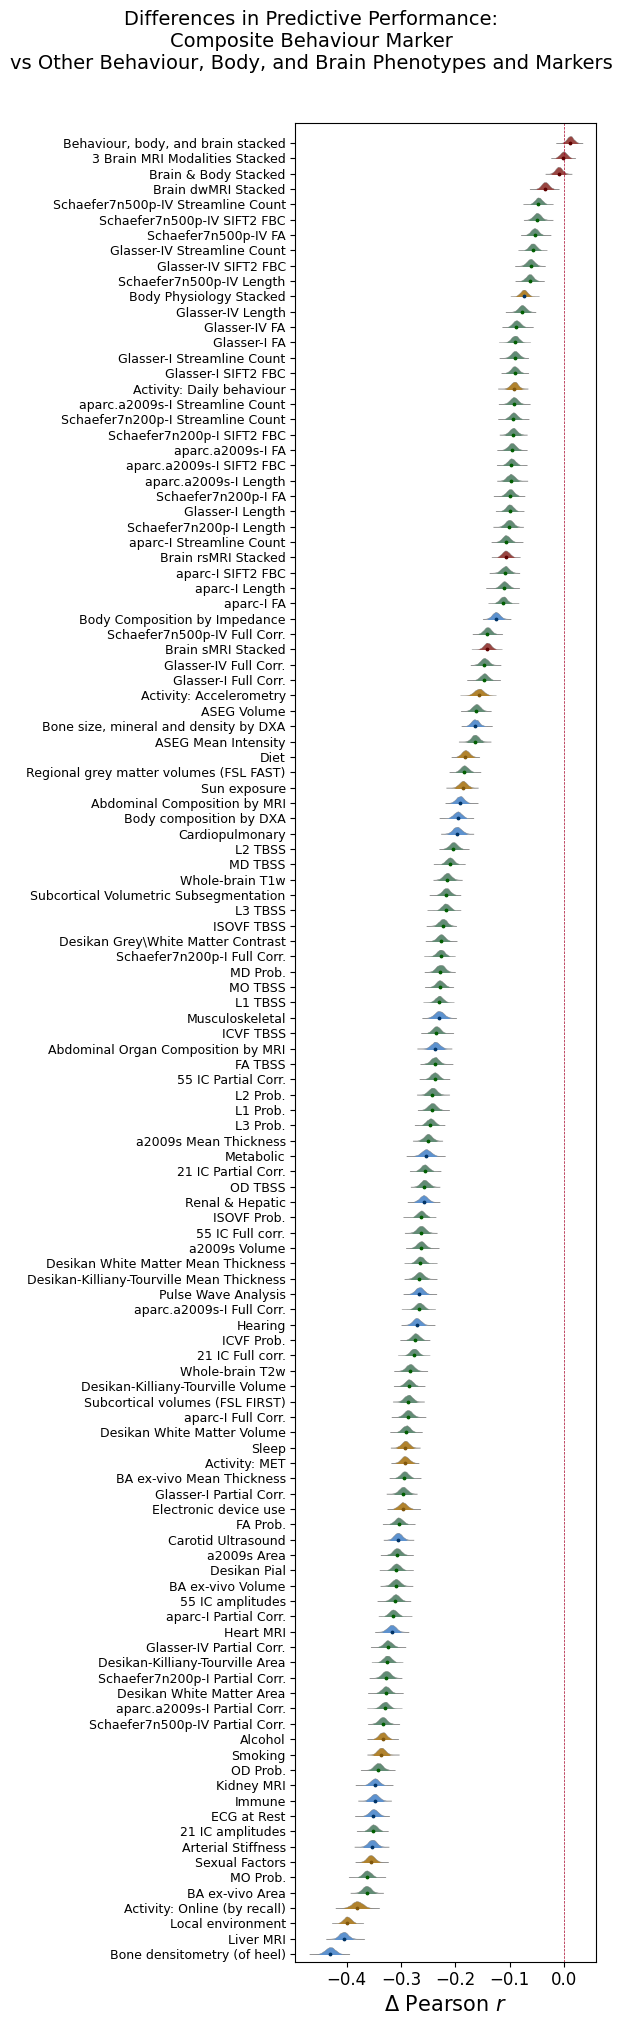

In [ ]:
# Plot composite behav vs the rest
from matplotlib.collections import PolyCollection
warnings.simplefilter(action='ignore', category=FutureWarning)
bootstrapping_path = r'Z:\UK_BB\brainbody\bootstrap\behav_vs_all'
os.makedirs(bootstrapping_path, exist_ok=True)

# Load  directories
delta_dfs = {}
delta_dir_body = os.path.join(bootstrapping_path, 'delta_results_body')
delta_dir_brain = os.path.join(bootstrapping_path, 'delta_results_brain')
delta_dir_behav = os.path.join(bootstrapping_path, 'delta_results_behav')
delta_dir_stacked = os.path.join(bootstrapping_path, 'delta_results_stacked')
violin_width = 0.9

# Load behav individual results
if os.path.exists(delta_dir_behav):
    delta_files = [f for f in os.listdir(delta_dir_behav) if f.startswith('delta_') and f.endswith('.csv')]
    for f in delta_files:
        delta_dfs[f.replace('.csv', '')] = pd.read_csv(os.path.join(delta_dir_behav, f))

# Load body individual results
if os.path.exists(delta_dir_body):
    delta_files = [f for f in os.listdir(delta_dir_body) if f.startswith('delta_') and f.endswith('.csv')]
    for f in delta_files:
        delta_dfs[f.replace('.csv', '')] = pd.read_csv(os.path.join(delta_dir_body, f))

# Load brain individual results
if os.path.exists(delta_dir_brain):
    delta_files = [f for f in os.listdir(delta_dir_brain) if f.startswith('delta_') and f.endswith('.csv')]
    for f in delta_files:
        delta_dfs[f.replace('.csv', '')] = pd.read_csv(os.path.join(delta_dir_brain, f))

# Load stacked results
if os.path.exists(delta_dir_stacked):
    delta_files = [f for f in os.listdir(delta_dir_stacked) if f.startswith('delta_') and f.endswith('.csv')]
    for f in delta_files:
        delta_dfs[f.replace('.csv', '')] = pd.read_csv(os.path.join(delta_dir_stacked, f))

# Prepare data for plotting - Pearson r
metric = 'delta_r'

# Define which modalities belong to which category
body_individual_modalities = modalities_body
brain_individual_modalities = modalities_brain
behav_individual_modalities = modalities_behav
stacked_modalities = ['allmri', 'dwi', 'rs', 'smri', 'brain-body', 'all', 'body', 'lifestyle-envir']

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 20))

# Combine all deltas for Pearson r
all_data = []
for mod_name, df in delta_dfs.items():
    if metric in df.columns:
        # Extract comparison name
        # Remove 'delta_' and '_vs_body' or similar suffixes
        comparison_name = mod_name.replace('delta_', '').replace('_vs_lifestyle-envir', '').replace('_individual', '')
        
        # Apply renaming
        comparison_name = modality_map.get(comparison_name, comparison_name)
        for val in df[metric]:
            all_data.append({'Comparison': comparison_name, 'Value': val})
    
if not all_data:
    print("No data found for plotting")
else:
    plot_df = pd.DataFrame(all_data)
    sorted_order = plot_df.groupby('Comparison')['Value'].median().sort_values().index

    # Determine colors based on modality type
    violin_colors = []
    for mod_name in sorted_order:
        # Get original name from reverse map
        reverse_modality_map = {v: k for k, v in modality_map.items()}
        original_name = reverse_modality_map.get(mod_name, mod_name)
        
        if original_name in stacked_modalities:
            violin_colors.append('#A73933FF')
        elif original_name in brain_individual_modalities:
            violin_colors.append('#5B9374FF')
        elif original_name in body_individual_modalities:
            violin_colors.append('#4A90E2FF')
        else:
            violin_colors.append('#C78A18FF')
    
    medians = plot_df.groupby('Comparison')['Value'].median().sort_values(ascending=False)

    # Create plot
    sns.violinplot(
        data=plot_df,
        x='Value',
        y='Comparison',
        order=sorted_order,
        ax=ax,
        palette=violin_colors,
        linewidth=0.3,
        linecolor="grey",
        width=violin_width,
        inner=None,
    )
    
    # Add median markers with different colors per category
    for j, modality in enumerate(sorted_order):
        median_val = medians[modality]
        reverse_modality_map = {v: k for k, v in modality_map.items()}
        original_name = reverse_modality_map.get(modality, modality)
        
        if original_name in stacked_modalities:
            marker_color = '#5E0000FF'
        elif original_name in brain_individual_modalities:
            marker_color = '#005E00FF'
        elif original_name in behav_individual_modalities:
            marker_color = "#80570CFF"
        else:
            marker_color = '#003366FF'
            
        ax.scatter(median_val, j, color=marker_color, s=3, zorder=5)

    ax.axvline(x=0, color='#A50026FF', linestyle='--', linewidth=0.5)
    ax.set_ylabel('')
    ax.set_xlabel('Δ Pearson $r$', fontsize=15)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=12)
    
    # Control plot margins
    n_categories = len(sorted_order)
    ax.set_ylim(-0.5, n_categories + 0.3)

    xlim = ax.get_xlim()
    half_height = violin_width / 2.0

    # Get only the violin body collections
    violin_collections = [c for c in ax.collections if isinstance(c, PolyCollection)]
    violin_collections = violin_collections[:len(sorted_order)]

    for j, coll in enumerate(violin_collections):
        rect = patches.Rectangle(
        (xlim[0], j),
        (xlim[1] - xlim[0]),
        half_height + 1e-9,
        transform=ax.transData,
        facecolor='none',
        edgecolor='none',
        linewidth=0
        )
        rect.set_visible(False)          
        ax.add_patch(rect)
        coll.set_clip_path(rect)

plt.suptitle('Differences in Predictive Performance:\nComposite Behaviour Marker\nvs Other Behaviour, Body, and Brain Phenotypes and Markers', 
             y=1.01, fontsize=14)
plt.tight_layout()
#plt.savefig(os.path.join(figure_path, 'supplem', 'delta_r_body_stack_vs_all.png'), dpi=300, bbox_inches='tight')
plt.show()

# Display stacking results

In [ ]:
# Pool all results together and add SD: behav, outer
five_folds = []
folds = range(0,5)

modalities = [
    'lifestyle-envir',
]

modality_names = {
    'lifestyle-envir': 'Behaviour, Lifestyle & Environment',
}

def count_csv_rows(file_path):
    with open(file_path) as f:
        return sum(1 for row in csv.reader(f)) - 1  # subtract header

def count_csv_columns(file_path):
    with open(file_path) as f:
        return len(next(csv.reader(f)))

algorithm = '0'
base_path = '/UK_BB/brainbody'
merge_type = 'outer'
glob_mod = f'lifestyle-envir_stack_{merge_type}'
output_result_path = '/UK_BB/brainbody/result/2level'
os.makedirs(output_result_path, exist_ok=True)

for modality in modalities:
    stacking_path = os.path.join(base_path, 'stacking', f'{modality}')

    for fold in folds:
        # Read the result file
        result = pd.read_csv(
            os.path.join(
                stacking_path,
                'folds', f'fold_{fold}', 'models', f'{modality}_{algorithm}_{merge_type}_stacked_result_fold_{fold}.csv'
            )
        )
            
        # Get number of features and subjects
        test_data_path = os.path.join(
            stacking_path,
            'features_test_level1_stacked_outer', f'features_test_level1_outer_g_matched_fold_{fold}.csv'
        )
        train_data_path = os.path.join(
            stacking_path,
            'features_train_level1_stacked_outer', f'features_train_level1_outer_g_matched_fold_{fold}.csv'
        )
        
        # Using the more efficient counting functions
        n_features = count_csv_columns(test_data_path) - 2  # subtracting eid and g columns
        n_test = count_csv_rows(test_data_path)
        n_train = count_csv_rows(train_data_path)
            
        result['N Features'] = n_features
        result['N Train'] = n_train
        result['N Test'] = n_test
            
        # Rename modality using the dictionary
        modality_rename = modality_names.get(modality, modality)
        result['Modality'] = modality_rename
            
        five_folds.append(result)

five_folds_all_modalities = pd.concat(five_folds, ignore_index=False)

# Remove underscores from column names
five_folds_all_modalities.columns = [col.replace('_', ' ') for col in five_folds_all_modalities.columns]

# Mean + SD across folds
# Metrics expected in "result" CSVs
all_metrics = [
    'Test R2', 'Test Pearson r', 'Test MSE', 'Test MAE',
    'Train R2', 'Train Pearson r', 'Train MSE', 'Train MAE'
]
# Keep only those that exist to avoid KeyErrors
metrics = [m for m in all_metrics if m in five_folds_all_modalities.columns]

# Aggregation: mean & std for metrics; take first for counts
agg_spec = {m: ['mean', 'std'] for m in metrics}
for c in ['N Train', 'N Test', 'N Features']:
    if c in five_folds_all_modalities.columns:
        agg_spec[c] = 'first'

five_folds_all_modalities_mean = (
    five_folds_all_modalities
    .groupby(['Modality'])
    .agg(agg_spec)
)

# Flatten MultiIndex columns
five_folds_all_modalities_mean.columns = [
    f"{col} {'Mean' if stat=='mean' else 'SD' if stat=='std' else ''}".strip()
    for col, stat in five_folds_all_modalities_mean.columns
]
five_folds_all_modalities_mean = five_folds_all_modalities_mean.reset_index()

# Rounding policy
round_map = {
    'Test R2 Mean': 3, 'Test R2 SD': 3,
    'Test Pearson r Mean': 3, 'Test Pearson r SD': 3,
    'Test MSE Mean': 3, 'Test MSE SD': 3,
    'Test MAE Mean': 3, 'Test MAE SD': 3,
    'Train R2 Mean': 3, 'Train R2 SD': 3,
    'Train Pearson r Mean': 3, 'Train Pearson r SD': 3,
    'Train MSE Mean': 3, 'Train MSE SD': 3,
    'Train MAE Mean': 3, 'Train MAE SD': 3
}
present_round_map = {k: v for k, v in round_map.items() if k in five_folds_all_modalities_mean.columns}
if present_round_map:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.round(present_round_map)

# Ensure counts are ints (if present)
for c in ['N Test', 'N Train', 'N Features']:
    if c in five_folds_all_modalities_mean.columns:
        five_folds_all_modalities_mean[c] = five_folds_all_modalities_mean[c].astype(int)

# Sort by a primary metric if available
if 'Test R2 Mean' in five_folds_all_modalities_mean.columns:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.sort_values(by='Test R2 Mean', ascending=False)

# Display the results
with pd.option_context('display.max_rows', None):
    display(five_folds_all_modalities_mean)

# Save final results
if 'Test R2' in five_folds_all_modalities.columns:
    five_folds_all_modalities = five_folds_all_modalities.sort_values(by='Test R2', ascending=False)

five_folds_all_modalities.to_excel(
    os.path.join(output_result_path, f'2level_result-folds_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)

five_folds_all_modalities_mean.to_excel(
    os.path.join(output_result_path, f'2level_result-mean_sd_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)

,Modality,Test R2 Mean,Test R2 SD,Test Pearson r Mean,Test Pearson r SD,Test MSE Mean,Test MSE SD,Test MAE Mean,Test MAE SD,Train R2 Mean,Train R2 SD,Train Pearson r Mean,Train Pearson r SD,Train MSE Mean,Train MSE SD,Train MAE Mean,Train MAE SD,N Train,N Test,N Features
0,"Behaviour, Lifestyle & Environment",0.227,0.018,0.479,0.02,0.771,0.026,0.694,0.011,0.393,0.013,0.65,0.01,0.607,0.013,0.616,0.007,25517,6380,12


In [ ]:
# Pool all results together and add SD: brain
five_folds = []
folds = range(0, 5)

modalities = [
    'smri',
    'dwi',
    'rs',
    'allmri'
]

modality_names = {
    'smri': 'sMRI',
    'dwi': 'dwMRI',
    'rs': 'rsMRI',
    'allmri': '3 Brain MRI Modalities Stacked'
}

def count_csv_rows(file_path):
    with open(file_path) as f:
        return sum(1 for _ in csv.reader(f)) - 1  # subtract header

def count_csv_columns(file_path):
    with open(file_path) as f:
        return len(next(csv.reader(f)))  # header length

algorithm = 'rf'
base_path = '/UK_BB/brainbody'
glob_mod = 'brain_stack'  # global mod name for saving
output_result_path = '/UK_BB/brainbody/result/2level'
os.makedirs(output_result_path, exist_ok=True)

for modality in modalities:
    stacking_path = os.path.join(base_path, 'stacking', 'brain', f'{modality}')

    for fold in folds:
        # Read the result file
        result_fp = os.path.join(
            stacking_path,
            f'folds', f'fold_{fold}', 'models', f'{modality}_{algorithm}_stacked_result_fold_{fold}.csv'
        )
        result = pd.read_csv(result_fp)
        
        # Paths for shapes
        test_data_path = os.path.join(
            stacking_path,
            'features_test_level1_stacked_inner', f'features_test_level1_inner_g_matched_fold_{fold}.csv'
        )
        train_data_path = os.path.join(
            stacking_path,
            'features_train_level1_stacked_inner', f'features_train_level1_inner_g_matched_fold_{fold}.csv'
        )
        
        # Efficient counts
        n_features = count_csv_columns(test_data_path) - 2  # subtract eid + g
        n_test = count_csv_rows(test_data_path)
        n_train = count_csv_rows(train_data_path)
        
        result['N Features'] = n_features
        result['N Train'] = n_train
        result['N Test'] = n_test
        
        # Rename modality
        modality_rename = modality_names.get(modality, modality)
        result['Modality'] = modality_rename
        
        # Domain
        if modality == 'smri':
            domain = 'sMRI'
        elif modality == 'dwi':
            domain = 'dwMRI'
        elif modality == 'rs':
            domain = 'rsMRI'
        elif modality == 'allmri':
            domain = 'MRI all'
        else:
            domain = 'Unknown'
        result['Domain'] = domain
        
        five_folds.append(result)

# Combine all folds across modalities
five_folds_all_modalities = pd.concat(five_folds, ignore_index=False)

# Normalize column names by removing underscores
five_folds_all_modalities.columns = [col.replace('_', ' ') for col in five_folds_all_modalities.columns]

# Mean + SD across folds
# Metrics expected in "result" CSVs
all_metrics = [
    'Test R2', 'Test Pearson r', 'Test MSE', 'Test MAE',
    'Train R2', 'Train Pearson r', 'Train MSE', 'Train MAE'
]
# Keep only those that exist to avoid KeyErrors
metrics = [m for m in all_metrics if m in five_folds_all_modalities.columns]

# Aggregation: mean & std for metrics; take first for counts
agg_spec = {m: ['mean', 'std'] for m in metrics}
for c in ['N Train', 'N Test', 'N Features']:
    if c in five_folds_all_modalities.columns:
        agg_spec[c] = 'first'

five_folds_all_modalities_mean = (
    five_folds_all_modalities
    .groupby(['Modality', 'Domain'])
    .agg(agg_spec)
)

# Flatten MultiIndex columns
five_folds_all_modalities_mean.columns = [
    (f"{col} {'Mean' if stat=='mean' else 'SD' if stat=='std' else ''}").strip()
    for col, stat in five_folds_all_modalities_mean.columns
]
five_folds_all_modalities_mean = five_folds_all_modalities_mean.reset_index()

# Rounding policy
round_map = {
    'Test R2 Mean': 3, 'Test R2 SD': 3,
    'Test Pearson r Mean': 3, 'Test Pearson r SD': 3,
    'Test MSE Mean': 3, 'Test MSE SD': 3,
    'Test MAE Mean': 3, 'Test MAE SD': 3,
    'Train R2 Mean': 3, 'Train R2 SD': 3,
    'Train Pearson r Mean': 3, 'Train Pearson r SD': 3,
    'Train MSE Mean': 3, 'Train MSE SD': 3,
    'Train MAE Mean': 3, 'Train MAE SD': 3
}
# Apply rounding only to present columns
present_round_map = {k: v for k, v in round_map.items() if k in five_folds_all_modalities_mean.columns}
if present_round_map:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.round(present_round_map)

# Ensure counts are ints (if present)
for c in ['N Test', 'N Train', 'N Features']:
    if c in five_folds_all_modalities_mean.columns:
        five_folds_all_modalities_mean[c] = five_folds_all_modalities_mean[c].astype(int)

# Sort by a primary metric if available
sort_key = 'Test R2 Mean' if 'Test R2 Mean' in five_folds_all_modalities_mean.columns else None
if sort_key:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.sort_values(by=sort_key, ascending=False)

# Display
with pd.option_context('display.max_rows', None):
    display(five_folds_all_modalities_mean.drop(columns='Domain'))

# Sort raw folds by Test R2 (if present) before saving
if 'Test R2' in five_folds_all_modalities.columns:
    five_folds_all_modalities = five_folds_all_modalities.sort_values(by='Test R2', ascending=False)

five_folds_all_modalities.to_excel(
    os.path.join(output_result_path, f'2level_result-folds_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)

# Save the Mean + SD table
five_folds_all_modalities_mean.to_excel(
    os.path.join(output_result_path, f'2level_result-mean_sd_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)

,Modality,Test R2 Mean,Test R2 SD,Test Pearson r Mean,Test Pearson r SD,Test MSE Mean,Test MSE SD,Test MAE Mean,Test MAE SD,Train R2 Mean,Train R2 SD,Train Pearson r Mean,Train Pearson r SD,Train MSE Mean,Train MSE SD,Train MAE Mean,Train MAE SD,N Train,N Test,N Features
0,3 Brain MRI Modalities Stacked,0.227,0.007,0.477,0.008,0.772,0.010,0.694,0.003,0.835,0.031,0.919,0.016,0.165,0.031,0.320,0.032,20273,5073,81
1,dwMRI,0.171,0.004,0.443,0.004,0.828,0.012,0.720,0.004,0.688,0.018,0.836,0.010,0.312,0.018,0.444,0.013,11360,5162,42
2,rsMRI,0.128,0.012,0.371,0.012,0.871,0.013,0.737,0.005,0.834,0.044,0.916,0.023,0.166,0.044,0.320,0.044,20324,5085,18
3,sMRI,0.098,0.011,0.337,0.014,0.901,0.023,0.749,0.009,0.411,0.010,0.652,0.008,0.589,0.010,0.608,0.005,21710,5415,21


In [ ]:
# Pool all results together and add SD: body, outer
five_folds = []
folds = range(0,5)

modalities = [
    'body',
]

modality_names = {
    'body': 'Body Stacked',
}

def count_csv_rows(file_path):
    with open(file_path) as f:
        return sum(1 for row in csv.reader(f)) - 1  # subtract header

def count_csv_columns(file_path):
    with open(file_path) as f:
        return len(next(csv.reader(f)))  # just read header row

algorithm = '0' # 0 = rf ofr outer output
base_path = '/UK_BB/brainbody'
merge_type = 'outer'
glob_mod = f'body_stack_{merge_type}'
output_result_path = '/UK_BB/brainbody/result/2level'
os.makedirs(output_result_path, exist_ok=True)

for modality in modalities:
    stacking_path = os.path.join(base_path, 'stacking', f'{modality}')

    for fold in folds:
        # Read the result file
        result = pd.read_csv(
            os.path.join(
                stacking_path,
                'folds', f'fold_{fold}', 'models', f'{modality}_{algorithm}_{merge_type}_stacked_result_fold_{fold}.csv'
            )
        )
            
        # Get number of features and subjects
        test_data_path = os.path.join(
            stacking_path,
            'features_test_level1_stacked_outer', f'features_test_level1_outer_g_matched_fold_{fold}.csv'
        )
        train_data_path = os.path.join(
            stacking_path,
            'features_train_level1_stacked_outer', f'features_train_level1_outer_g_matched_fold_{fold}.csv'
        )
        
        # Using the more efficient counting functions
        n_features = count_csv_columns(test_data_path) - 2  # subtracting eid and g columns
        n_test = count_csv_rows(test_data_path)
        n_train = count_csv_rows(train_data_path)
            
        result['N Features'] = n_features
        result['N Train'] = n_train
        result['N Test'] = n_test
            
        # Rename modality using the dictionary
        modality_rename = modality_names.get(modality, modality)
        result['Modality'] = modality_rename
            
        five_folds.append(result)

five_folds_all_modalities = pd.concat(five_folds, ignore_index=False)

# Remove underscores from column names
five_folds_all_modalities.columns = [col.replace('_', ' ') for col in five_folds_all_modalities.columns]

# Mean + SD across folds

# Metrics expected in "result" CSVs
all_metrics = [
    'Test R2', 'Test Pearson r', 'Test MSE', 'Test MAE',
    'Train R2', 'Train Pearson r', 'Train MSE', 'Train MAE'
]
# Keep only those that exist to avoid KeyErrors
metrics = [m for m in all_metrics if m in five_folds_all_modalities.columns]

# Aggregation: mean & std for metrics; take first for counts
agg_spec = {m: ['mean', 'std'] for m in metrics}
for c in ['N Train', 'N Test', 'N Features']:
    if c in five_folds_all_modalities.columns:
        agg_spec[c] = 'first'

five_folds_all_modalities_mean = (
    five_folds_all_modalities
    .groupby(['Modality'])
    .agg(agg_spec)
)

# Flatten MultiIndex columns
five_folds_all_modalities_mean.columns = [
    f"{col} {'Mean' if stat=='mean' else 'SD' if stat=='std' else ''}".strip()
    for col, stat in five_folds_all_modalities_mean.columns
]
five_folds_all_modalities_mean = five_folds_all_modalities_mean.reset_index()

# Rounding policy
round_map = {
    'Test R2 Mean': 3, 'Test R2 SD': 3,
    'Test Pearson r Mean': 2, 'Test Pearson r SD': 2,
    'Test MSE Mean': 3, 'Test MSE SD': 3,
    'Test MAE Mean': 3, 'Test MAE SD': 3,
    'Train R2 Mean': 3, 'Train R2 SD': 3,
    'Train Pearson r Mean': 2, 'Train Pearson r SD': 2,
    'Train MSE Mean': 2, 'Train MSE SD': 2,
    'Train MAE Mean': 2, 'Train MAE SD': 2
}
present_round_map = {k: v for k, v in round_map.items() if k in five_folds_all_modalities_mean.columns}
if present_round_map:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.round(present_round_map)

# Ensure counts are ints (if present)
for c in ['N Test', 'N Train', 'N Features']:
    if c in five_folds_all_modalities_mean.columns:
        five_folds_all_modalities_mean[c] = five_folds_all_modalities_mean[c].astype(int)

# Sort by a primary metric if available
if 'Test R2 Mean' in five_folds_all_modalities_mean.columns:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.sort_values(by='Test R2 Mean', ascending=False)

# Display the results
with pd.option_context('display.max_rows', None):
    display(five_folds_all_modalities_mean)

# Save final results
if 'Test R2' in five_folds_all_modalities.columns:
    five_folds_all_modalities = five_folds_all_modalities.sort_values(by='Test R2', ascending=False)

five_folds_all_modalities.to_excel(
    os.path.join(output_result_path, f'2level_result-folds_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)

five_folds_all_modalities_mean.to_excel(
    os.path.join(output_result_path, f'2level_result-mean_sd_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)


,Modality,Test R2 Mean,Test R2 SD,Test Pearson r Mean,Test Pearson r SD,Test MSE Mean,Test MSE SD,Test MAE Mean,Test MAE SD,Train R2 Mean,Train R2 SD,Train Pearson r Mean,Train Pearson r SD,Train MSE Mean,Train MSE SD,Train MAE Mean,Train MAE SD,N Train,N Test,N Features
0,Body Stacked,0.163,0.012,0.4,0.02,0.835,0.022,0.722,0.009,0.357,0.008,0.62,0.01,0.64,0.01,0.63,0.0,25517,6380,19


In [ ]:
# Pool all results together and add SD: brain + body, outer
five_folds = []
folds = range(0,5)

modalities = [
    'brain-body',
]

modality_names = {
    'brain-body': 'Body and Brain Stacked',
}

def count_csv_rows(file_path):
    with open(file_path) as f:
        return sum(1 for row in csv.reader(f)) - 1  # subtract header

def count_csv_columns(file_path):
    with open(file_path) as f:
        return len(next(csv.reader(f)))  # just read header row

algorithm = '0'  # 0 = rf for outer output
base_path = '/UK_BB/brainbody'
merge_type = 'outer'
glob_mod = f'brain_and_body_stack_{merge_type}'
output_result_path = '/UK_BB/brainbody/result/2level'
os.makedirs(output_result_path, exist_ok=True)

for modality in modalities:
    stacking_path = os.path.join(base_path, 'stacking', f'{modality}')

    for fold in folds:
        # Read the result file
        result = pd.read_csv(
            os.path.join(
                stacking_path,
                'folds', f'fold_{fold}', 'models', f'{modality}_{algorithm}_{merge_type}_stacked_result_fold_{fold}.csv'
            )
        )
            
        # Get number of features and subjects
        test_data_path = os.path.join(
            stacking_path,
            'features_test_level1_stacked_outer', f'features_test_level1_outer_g_matched_fold_{fold}.csv'
        )
        train_data_path = os.path.join(
            stacking_path,
            'features_train_level1_stacked_outer', f'features_train_level1_outer_g_matched_fold_{fold}.csv'
        )
        
        # Using the more efficient counting functions
        n_features = count_csv_columns(test_data_path) - 2  # subtracting eid and g columns
        n_test = count_csv_rows(test_data_path)
        n_train = count_csv_rows(train_data_path)
            
        result['N Features'] = n_features
        result['N Train'] = n_train
        result['N Test'] = n_test
            
        # Rename modality using the dictionary
        modality_rename = modality_names.get(modality, modality)
        result['Modality'] = modality_rename
            
        five_folds.append(result)

five_folds_all_modalities = pd.concat(five_folds, ignore_index=False)

# Remove underscores from column names
five_folds_all_modalities.columns = [col.replace('_', ' ') for col in five_folds_all_modalities.columns]

# Mean + SD across folds

# Metrics expected in "result" CSVs
all_metrics = [
    'Test R2', 'Test Pearson r', 'Test MSE', 'Test MAE',
    'Train R2', 'Train Pearson r', 'Train MSE', 'Train MAE'
]
metrics = [m for m in all_metrics if m in five_folds_all_modalities.columns]

# Aggregation: mean & std for metrics; take first for counts
agg_spec = {m: ['mean', 'std'] for m in metrics}
for c in ['N Train', 'N Test', 'N Features']:
    if c in five_folds_all_modalities.columns:
        agg_spec[c] = 'first'

five_folds_all_modalities_mean = (
    five_folds_all_modalities
    .groupby(['Modality'])
    .agg(agg_spec)
)

# Flatten MultiIndex columns
five_folds_all_modalities_mean.columns = [
    f"{col} {'Mean' if stat=='mean' else 'SD' if stat=='std' else ''}".strip()
    for col, stat in five_folds_all_modalities_mean.columns
]
five_folds_all_modalities_mean = five_folds_all_modalities_mean.reset_index()

# Rounding policy
round_map = {
    'Test R2 Mean': 3, 'Test R2 SD': 3,
    'Test Pearson r Mean': 3, 'Test Pearson r SD': 3,
    'Test MSE Mean': 3, 'Test MSE SD': 3,
    'Test MAE Mean': 3, 'Test MAE SD': 3,
    'Train R2 Mean': 3, 'Train R2 SD': 3,
    'Train Pearson r Mean': 3, 'Train Pearson r SD': 3,
    'Train MSE Mean': 3, 'Train MSE SD': 3,
    'Train MAE Mean': 3, 'Train MAE SD': 3
}
present_round_map = {k: v for k, v in round_map.items() if k in five_folds_all_modalities_mean.columns}
if present_round_map:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.round(present_round_map)

# Ensure counts are ints (if present)
for c in ['N Test', 'N Train', 'N Features']:
    if c in five_folds_all_modalities_mean.columns:
        five_folds_all_modalities_mean[c] = five_folds_all_modalities_mean[c].astype(int)

# Sort by a primary metric if available
if 'Test R2 Mean' in five_folds_all_modalities_mean.columns:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.sort_values(by='Test R2 Mean', ascending=False)

# Display
with pd.option_context('display.max_rows', None):
    display(five_folds_all_modalities_mean)

# Save outputs
if 'Test R2' in five_folds_all_modalities.columns:
    five_folds_all_modalities = five_folds_all_modalities.sort_values(by='Test R2', ascending=False)

five_folds_all_modalities.to_excel(
    os.path.join(output_result_path, f'2level_result-folds_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)

five_folds_all_modalities_mean.to_excel(
    os.path.join(output_result_path, f'2level_result-mean_sd_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)


,Modality,Test R2 Mean,Test R2 SD,Test Pearson r Mean,Test Pearson r SD,Test MSE Mean,Test MSE SD,Test MAE Mean,Test MAE SD,Train R2 Mean,Train R2 SD,Train Pearson r Mean,Train Pearson r SD,Train MSE Mean,Train MSE SD,Train MAE Mean,Train MAE SD,N Train,N Test,N Features
0,Body and Brain Stacked,0.218,0.003,0.469,0.003,0.781,0.011,0.698,0.003,0.706,0.022,0.85,0.013,0.294,0.022,0.398,0.023,25517,6380,100


In [ ]:
# Pool all results together and add SD: all, outer
five_folds = []
folds = range(0,5)

modalities = [
    'all',
]

modality_names = {
    'all': 'Behaviour, Body & Brain Stacked',
}

def count_csv_rows(file_path):
    with open(file_path) as f:
        return sum(1 for row in csv.reader(f)) - 1  # subtract header

def count_csv_columns(file_path):
    with open(file_path) as f:
        return len(next(csv.reader(f)))  # just read header row

algorithm = 'rf'
base_path = '/UK_BB/brainbody'
merge_type = 'outer'
glob_mod = f'brain_and_body_stack_{merge_type}'
output_result_path = '/UK_BB/brainbody/result/2level'
os.makedirs(output_result_path, exist_ok=True)

for modality in modalities:
    stacking_path = os.path.join(base_path, 'stacking', f'{modality}')

    for fold in folds:
        # Read the result file
        result = pd.read_csv(
            os.path.join(
                stacking_path,
                'folds', f'fold_{fold}', 'models', f'{modality}_{algorithm}_{merge_type}_stacked_result_fold_{fold}.csv'
            )
        )
            
        # Get number of features and subjects
        test_data_path = os.path.join(
            stacking_path,
            'features_test_level1_stacked_outer', f'features_test_level1_outer_g_matched_fold_{fold}.csv'
        )
        train_data_path = os.path.join(
            stacking_path,
            'features_train_level1_stacked_outer', f'features_train_level1_outer_g_matched_fold_{fold}.csv'
        )
        
        # Using the more efficient counting functions
        n_features = count_csv_columns(test_data_path) - 2  # subtracting eid and g columns
        n_test = count_csv_rows(test_data_path)
        n_train = count_csv_rows(train_data_path)
            
        result['N Features'] = n_features
        result['N Train'] = n_train
        result['N Test'] = n_test
            
        # Rename modality using the dictionary
        modality_rename = modality_names.get(modality, modality)
        result['Modality'] = modality_rename
            
        five_folds.append(result)

five_folds_all_modalities = pd.concat(five_folds, ignore_index=False)

# Remove underscores from column names
five_folds_all_modalities.columns = [col.replace('_', ' ') for col in five_folds_all_modalities.columns]

# Mean + SD across folds

# Metrics expected in "result" CSVs
all_metrics = [
    'Test R2', 'Test Pearson r', 'Test MSE', 'Test MAE',
    'Train R2', 'Train Pearson r', 'Train MSE', 'Train MAE'
]
metrics = [m for m in all_metrics if m in five_folds_all_modalities.columns]

# Aggregation: mean & std for metrics; take first for counts
agg_spec = {m: ['mean', 'std'] for m in metrics}
for c in ['N Train', 'N Test', 'N Features']:
    if c in five_folds_all_modalities.columns:
        agg_spec[c] = 'first'

five_folds_all_modalities_mean = (
    five_folds_all_modalities
    .groupby(['Modality'])
    .agg(agg_spec)
)

# Flatten MultiIndex columns
five_folds_all_modalities_mean.columns = [
    f"{col} {'Mean' if stat=='mean' else 'SD' if stat=='std' else ''}".strip()
    for col, stat in five_folds_all_modalities_mean.columns
]
five_folds_all_modalities_mean = five_folds_all_modalities_mean.reset_index()

# Rounding policy
round_map = {
    'Test R2 Mean': 3, 'Test R2 SD': 3,
    'Test Pearson r Mean': 3, 'Test Pearson r SD': 3,
    'Test MSE Mean': 3, 'Test MSE SD': 3,
    'Test MAE Mean': 3, 'Test MAE SD': 3,
    'Train R2 Mean': 3, 'Train R2 SD': 3,
    'Train Pearson r Mean': 3, 'Train Pearson r SD': 3,
    'Train MSE Mean': 3, 'Train MSE SD': 3,
    'Train MAE Mean': 3, 'Train MAE SD': 3
}
present_round_map = {k: v for k, v in round_map.items() if k in five_folds_all_modalities_mean.columns}
if present_round_map:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.round(present_round_map)

# Ensure counts are ints (if present)
for c in ['N Test', 'N Train', 'N Features']:
    if c in five_folds_all_modalities_mean.columns:
        five_folds_all_modalities_mean[c] = five_folds_all_modalities_mean[c].astype(int)

# Sort by a primary metric if available
if 'Test R2 Mean' in five_folds_all_modalities_mean.columns:
    five_folds_all_modalities_mean = five_folds_all_modalities_mean.sort_values(by='Test R2 Mean', ascending=False)

# Display
with pd.option_context('display.max_rows', None):
    display(five_folds_all_modalities_mean)

# Save outputs
if 'Test R2' in five_folds_all_modalities.columns:
    five_folds_all_modalities = five_folds_all_modalities.sort_values(by='Test R2', ascending=False)

five_folds_all_modalities.to_excel(
    os.path.join(output_result_path, f'2level_result-folds_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)

five_folds_all_modalities_mean.to_excel(
    os.path.join(output_result_path, f'2level_result-mean_sd_{glob_mod}.xlsx'),
    index=False,
    engine='openpyxl'
)


,Modality,Test R2 Mean,Test R2 SD,Test Pearson r Mean,Test Pearson r SD,Test MSE Mean,Test MSE SD,Test MAE Mean,Test MAE SD,Train R2 Mean,Train R2 SD,Train Pearson r Mean,Train Pearson r SD,Train MSE Mean,Train MSE SD,Train MAE Mean,Train MAE SD,N Train,N Test,N Features
0,"Behaviour, Body & Brain Stacked",0.236,0.004,0.49,0.004,0.762,0.012,0.689,0.004,0.717,0.02,0.858,0.011,0.283,0.02,0.394,0.021,25517,6380,112
